# Analisi di Regressione - Indici Psicologici e Ansia

## 1. Import delle Librerie Necessarie

In [167]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Scikit-learn
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Scipy
from scipy.stats import pearsonr

## 2. Caricamento e Preparazione dei Dati

In [168]:
# Esecuzione script setup e pulizia dati
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

KeyboardInterrupt: 

In [ ]:
# Esecuzione notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


STDERR: [NbConvertApp] Converting notebook ../notebook/pulizia.ipynb to notebook
c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\zmq\_future.py:718: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()
[NbConvertApp] Writing 197036 bytes to ..\notebook\pulizia.nbconvert.ipynb



In [ ]:
# Connessione al database e caricamento dati
conn = get_mysql_connection()
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)
conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
print(f"\nTipo di dati:")
print(df.dtypes)
print(f"\nPrime righe:")
df.head()

Dataset caricato: 148 righe, 37 colonne

Tipo di dati:
id                   int64
email               object
contesto            object
età                  int64
genere              object
area_geo            object
anni_esperienza    float64
Item_1               int64
Item_2               int64
Item_3               int64
Item_4               int64
Item_5               int64
Item_6             float64
Item_7             float64
Item_8             float64
Item_9             float64
Item_10            float64
Item_11            float64
Item_12            float64
Item_13            float64
Item_14            float64
Item_15            float64
Item_16            float64
Item_17            float64
Item_18            float64
Item_19            float64
Item_20            float64
Item_21              int64
Item_22              int64
Item_23              int64
Item_24              int64
Item_25              int64
Item_26              int64
Item_27              int64
Item_28              int64


C:\Users\Utente\AppData\Local\Temp\ipykernel_28024\1536176296.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


In [ ]:
# Verifica informazioni dataset
print("\nInfo Dataset:")
df.info()
print(f"\nValori mancanti:\n{df.isnull().sum()}")


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               148 non-null    int64  
 1   email            13 non-null     object 
 2   contesto         148 non-null    object 
 3   età              148 non-null    int64  
 4   genere           148 non-null    object 
 5   area_geo         148 non-null    object 
 6   anni_esperienza  148 non-null    float64
 7   Item_1           148 non-null    int64  
 8   Item_2           148 non-null    int64  
 9   Item_3           148 non-null    int64  
 10  Item_4           148 non-null    int64  
 11  Item_5           148 non-null    int64  
 12  Item_6           145 non-null    float64
 13  Item_7           145 non-null    float64
 14  Item_8           145 non-null    float64
 15  Item_9           146 non-null    float64
 16  Item_10          144 non-null    float64
 17  I

## 3. Calcolo degli Indici Psicologici

In [ ]:
# Indici principali
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

In [ ]:
# Ansia totale
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

In [ ]:
# Indici derivati
df["vulnerabilita"] = (df["perfezionismo"] + df["ansia"]) / 2
df["resilienza"] = (df["coping"] - df["ansia"])
df["gap"] = (df["Item_8"] - df["coping"])
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)
df["intensita_sintomatica"] = df[["Item_20", "Item_21", "Item_22"]].mean(axis=1)

In [ ]:
# Elenco variabili disponibili
vars_to_analyze = [
    'ansia', 'coping', 'perfezionismo', 'vulnerabilita', 
    'resilienza', 'gap', 'evitamento', 'intensita_sintomatica',
    'impatto_ansia', 'ansia_prestazione', 'ansia_accademica', 
    'ansia_lavorativa'
]

vars_available = [v for v in vars_to_analyze if v in df.columns]
print(f"Variabili disponibili: {len(vars_available)}/{len(vars_to_analyze)}")
print(vars_available)

# Statistiche descrittive
print(f"\nStatistiche descrittive:")
df[vars_available].describe()

Variabili disponibili: 12/12
['ansia', 'coping', 'perfezionismo', 'vulnerabilita', 'resilienza', 'gap', 'evitamento', 'intensita_sintomatica', 'impatto_ansia', 'ansia_prestazione', 'ansia_accademica', 'ansia_lavorativa']

Statistiche descrittive:


,ansia,coping,perfezionismo,vulnerabilita,resilienza,gap,evitamento,intensita_sintomatica,impatto_ansia,ansia_prestazione,ansia_accademica,ansia_lavorativa
count,148.000000,148.000000,82.000000,82.000000,148.000000,145.000000,148.000000,148.000000,148.000000,148.000000,146.000000,92.000000
mean,2.918999,3.023649,3.134146,2.988640,0.104649,-0.444828,2.417793,2.930180,3.185135,3.239181,2.600457,3.048913
std,0.863239,0.785356,1.026798,0.837343,1.423650,1.587021,1.085315,1.096792,0.912227,0.931500,0.984989,0.919298
min,1.214286,1.000000,1.000000,1.416667,-3.750000,-3.500000,1.000000,1.000000,1.200000,1.142857,1.000000,1.000000
25%,2.267857,2.500000,2.250000,2.380208,-0.843750,-1.750000,1.500000,2.000000,2.600000,2.553571,2.000000,2.250000
50%,2.901786,3.000000,3.250000,2.976190,0.300595,-0.500000,2.250000,2.666667,3.100000,3.196429,2.500000,3.000000
75%,3.596726,3.750000,3.937500,3.573661,1.126488,0.500000,3.250000,3.750000,3.800000,4.000000,3.250000,3.750000
max,4.869048,4.750000,5.000000,4.803571,2.845238,3.750000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## 4. Analisi Esplorativa - Distribuzioni

In [ ]:
# Funzione per salvare i grafici
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """Salva figura nella cartella images"""
    if os.path.exists(f"../images/{fig_id}.{fig_extension}"):
        os.remove(f"../images/{fig_id}.{fig_extension}")
    path = os.path.join("../images", fig_id + "." + fig_extension)
    os.makedirs("../images", exist_ok=True)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

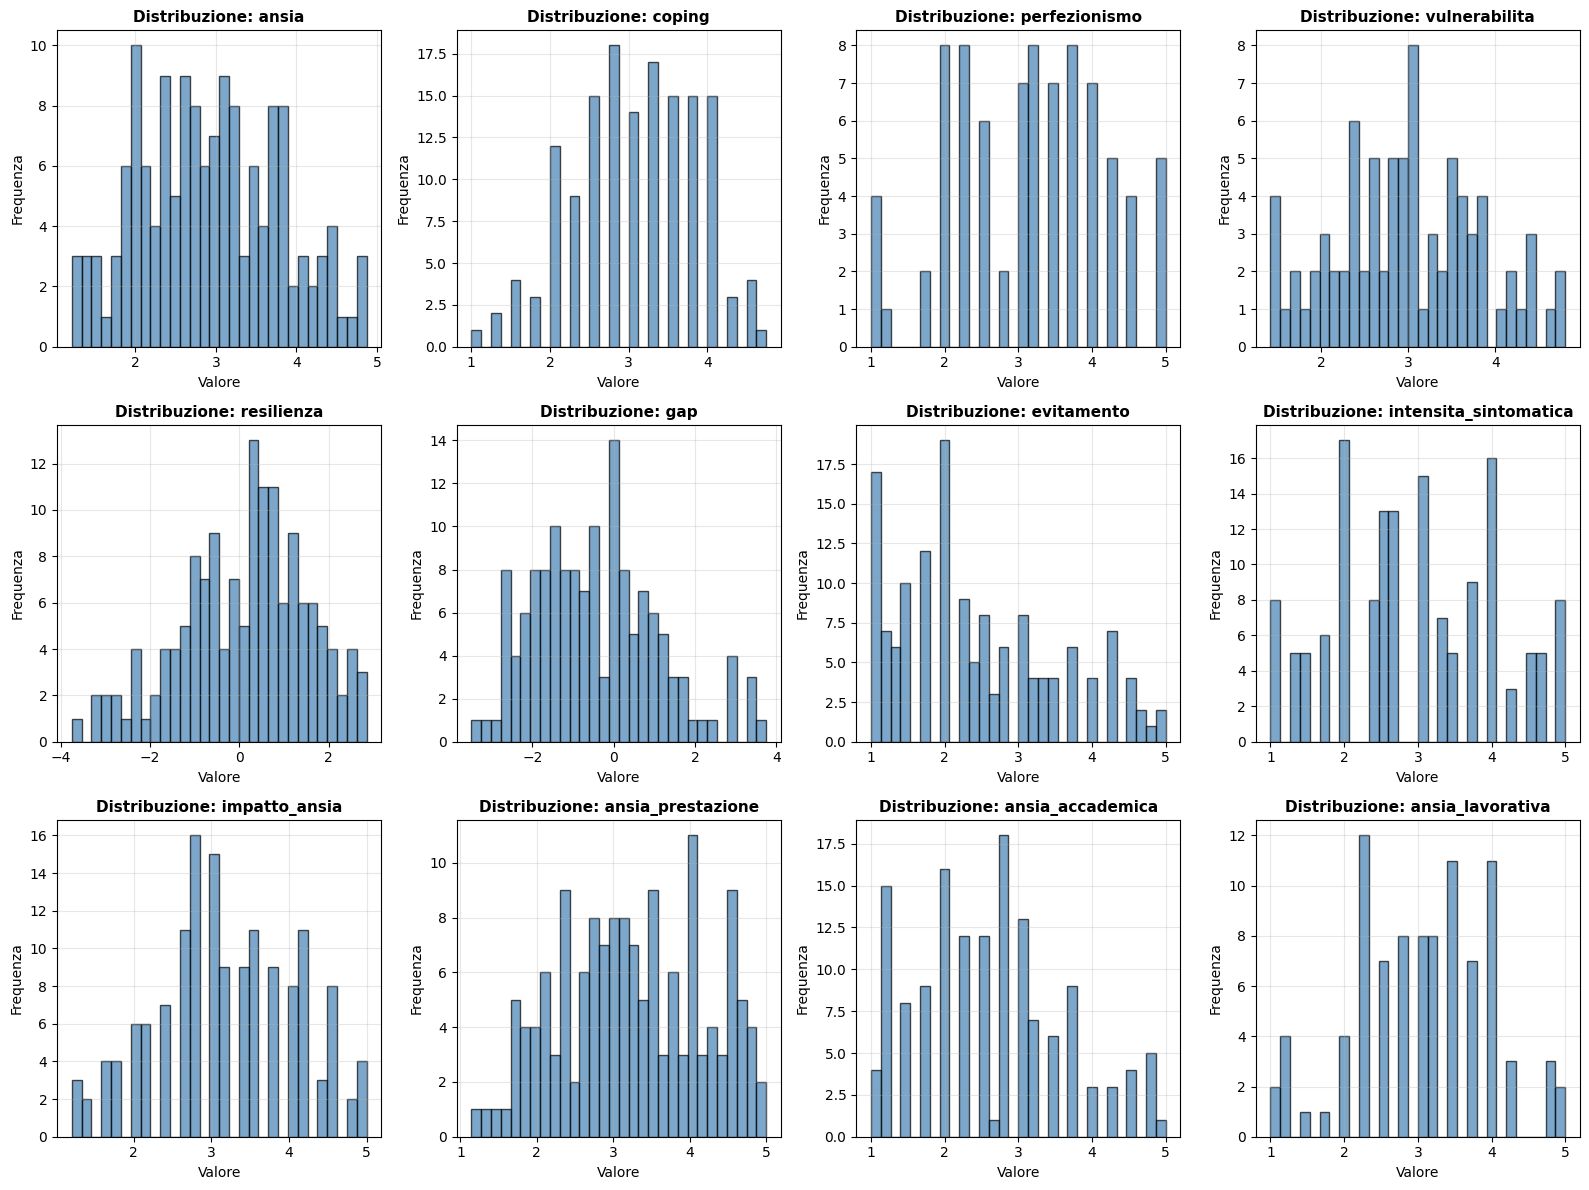

In [ ]:
# Distribuzioni degli indici principali
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, var in enumerate(vars_available):
    axes[idx].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuzione: {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Valore')
    axes[idx].set_ylabel('Frequenza')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("distribuzioni_indici")
plt.show()

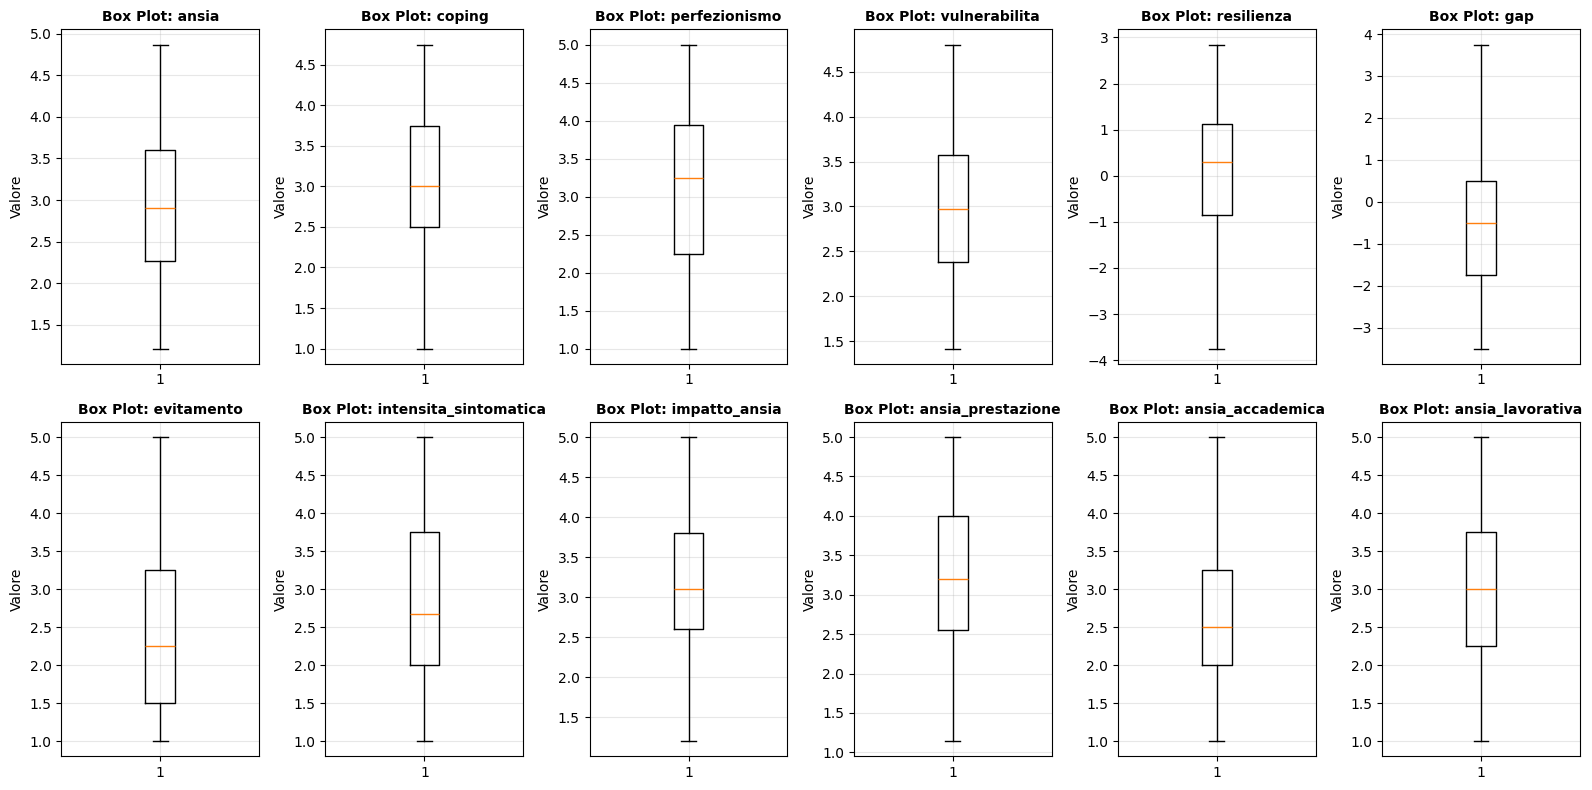

In [ ]:
# Box plot per identificare outlier
fig, axes = plt.subplots(2, 6, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(vars_available):
    axes[idx].boxplot(df[var].dropna(), vert=True)
    axes[idx].set_title(f'Box Plot: {var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Valore')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("boxplot_indici")
plt.show()

## 5. Analisi delle Correlazioni

In [ ]:
# Matrice di correlazione Pearson
corr_matrix = df[vars_available].corr(method='pearson')

print(f"Matrice di correlazione {corr_matrix.shape}:")
print(corr_matrix.round(3))

Matrice di correlazione (12, 12):
                       ansia  coping  perfezionismo  vulnerabilita  \
ansia                  1.000  -0.490          0.611          0.874   
coping                -0.490   1.000         -0.275         -0.411   
perfezionismo          0.611  -0.275          1.000          0.919   
vulnerabilita          0.874  -0.411          0.919          1.000   
resilienza            -0.877   0.849         -0.520         -0.753   
gap                    0.736  -0.673          0.424          0.645   
evitamento             0.790  -0.502          0.446          0.661   
intensita_sintomatica  0.804  -0.410          0.594          0.751   
impatto_ansia          0.801  -0.425          0.573          0.747   
ansia_prestazione      0.922  -0.483          0.646          0.853   
ansia_accademica       0.894  -0.463          0.485          0.757   
ansia_lavorativa       0.862  -0.318          0.350          0.655   

                       resilienza    gap  evitamento  i

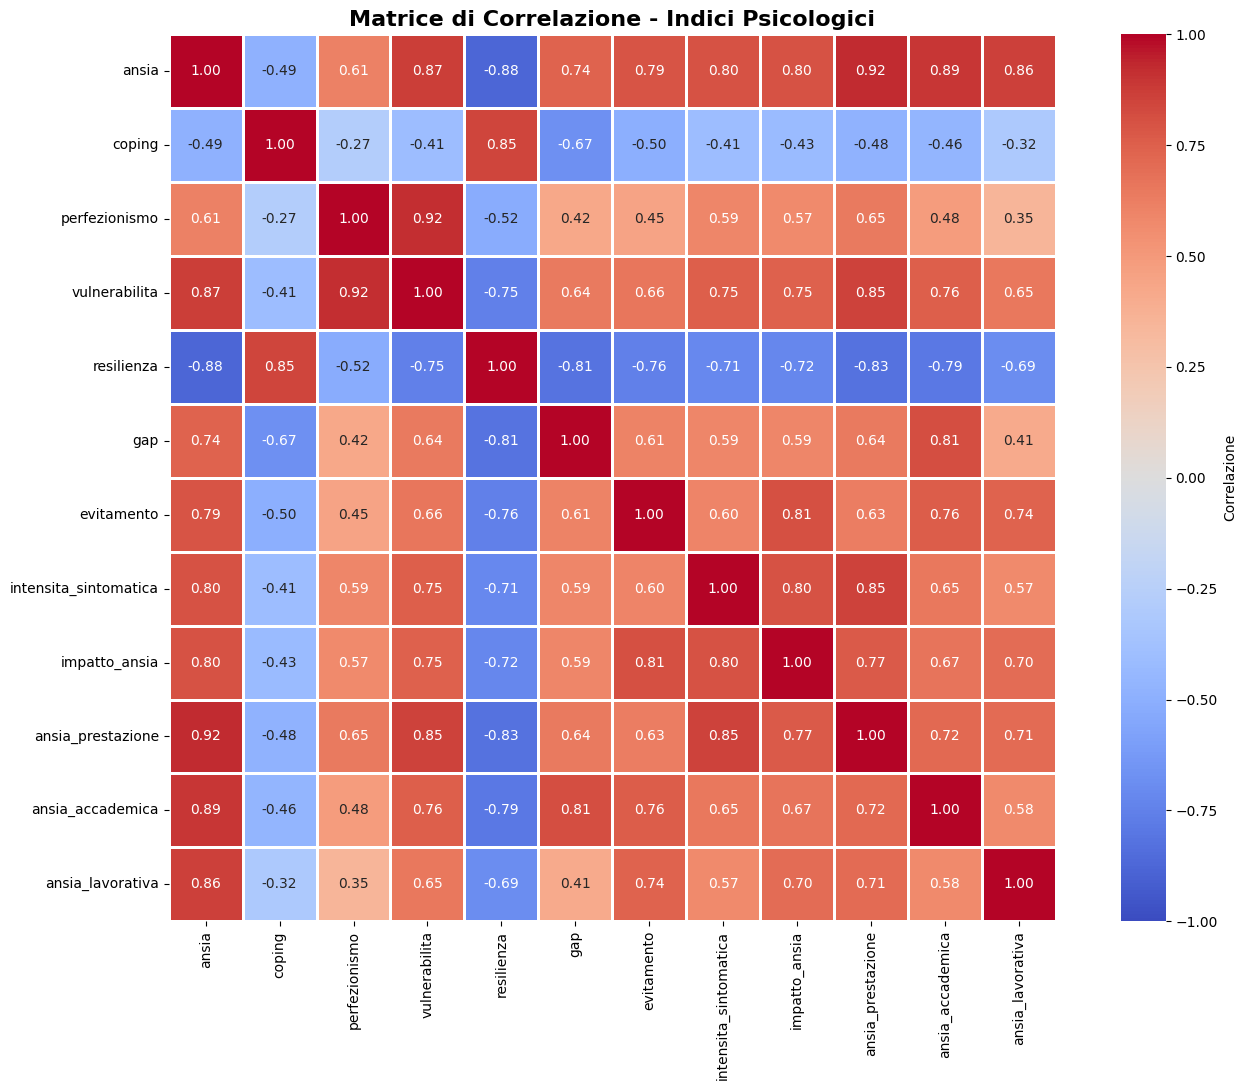

In [ ]:
# Heatmap della matrice di correlazione
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'},
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione - Indici Psicologici', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig("matrice_correlazione")
plt.show()

In [ ]:
# Calcolo p-value e ranking delle correlazioni
df_clean = df[vars_available].dropna()
correlations_list = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        r, p_value = pearsonr(df_clean[var1], df_clean[var2])
        
        correlations_list.append({
            'Variabile 1': var1,
            'Variabile 2': var2,
            'Correlazione': corr_value,
            'Abs_Corr': abs(corr_value),
            'P-value': p_value,
            'Significativa (p<0.05)': 'Sì' if p_value < 0.05 else 'No'
        })

corr_df = pd.DataFrame(correlations_list)
corr_df_sorted = corr_df.sort_values('Abs_Corr', ascending=False)

print(f"\nTOP 15 CORRELAZIONI (su {len(corr_df)} totali)")
print(corr_df_sorted.head(15).to_string(index=False))


TOP 15 CORRELAZIONI (su 66 totali)
          Variabile 1           Variabile 2  Correlazione  Abs_Corr      P-value Significativa (p<0.05)
                ansia     ansia_prestazione      0.922054  0.922054 2.082988e-13                     Sì
        perfezionismo         vulnerabilita      0.918575  0.918575 2.414804e-13                     Sì
                ansia      ansia_accademica      0.893663  0.893663 4.033946e-13                     Sì
                ansia            resilienza     -0.876837  0.876837 2.853527e-12                     Sì
                ansia         vulnerabilita      0.874435  0.874435 2.639129e-11                     Sì
                ansia      ansia_lavorativa      0.862286  0.862286 5.966684e-10                     Sì
        vulnerabilita     ansia_prestazione      0.853307  0.853307 1.133883e-10                     Sì
intensita_sintomatica     ansia_prestazione      0.853021  0.853021 4.060124e-08                     Sì
               coping       

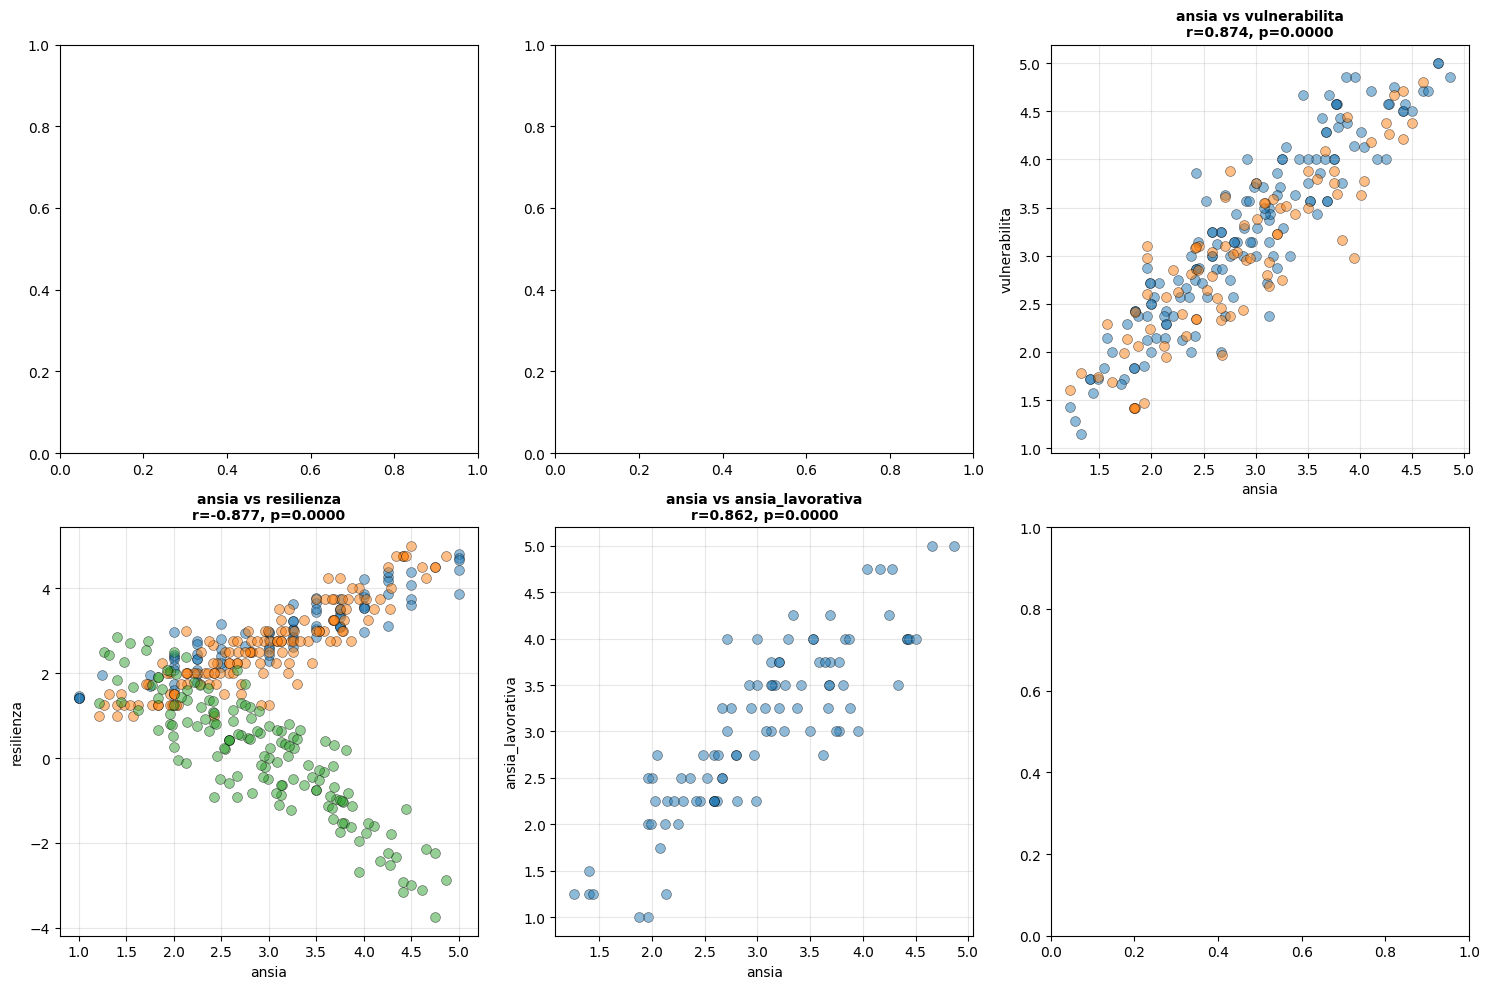

In [ ]:
# Visualizzazione scatter plot delle correlazioni più significative
top_correlations = corr_df_sorted.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, row in top_correlations.iterrows():
    ax = axes[idx % 6]
    var1, var2 = row['Variabile 1'], row['Variabile 2']
    corr_val = row['Correlazione']
    p_val = row['P-value']
    
    ax.scatter(df[var1], df[var2], alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(var1, fontsize=10)
    ax.set_ylabel(var2, fontsize=10)
    ax.set_title(f'{var1} vs {var2}\nr={corr_val:.3f}, p={p_val:.4f}', 
                fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("scatter_correlazioni_top6")
plt.show()

## 6. Feature Engineering e Confronto Modelli

In [ ]:
# Definisci coppie target per la regressione
regression_targets = [
    ('ansia', 'coping'),
    ('ansia', 'gap'),
    ('ansia', 'evitamento'),
    ('perfezionismo', 'coping'),
    ('resilienza', 'evitamento'),
]

# Definisci feature sets
feature_sets = {
    'Univariata': lambda x, y: [x],
    'Multivariata (3 var)': lambda x, y: [x, 'perfezionismo', 'vulnerabilita'],
    'Multivariata (5 var)': lambda x, y: [x, 'perfezionismo', 'vulnerabilita', 'impatto_ansia', 'intensita_sintomatica'],
    'Multivariata (tutte)': lambda x, y: [v for v in vars_available if v != y]
}

results_comparison = []

for target_x, target_y in regression_targets:
    print(f"\n{'='*70}")
    print(f"REGRESSIONE: {target_x} → {target_y}")
    print(f"{'='*70}")
    
    df_clean_reg = df[[target_x, target_y] + vars_available].dropna()
    
    if len(df_clean_reg) < 10:
        print(f"Dataset troppo piccolo ({len(df_clean_reg)} campioni), saltato")
        continue
    
    for feature_name, feature_func in feature_sets.items():
        features = feature_func(target_x, target_y)
        features = [f for f in features if f in df_clean_reg.columns]
        
        if not features:
            continue
        
        X = df_clean_reg[features].values
        y = df_clean_reg[target_y].values
        
        # Normalizza
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        # Linear Regression
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        results_comparison.append({
            'Predittore': target_x,
            'Target': target_y,
            'Modello': 'Linear',
            'Features': feature_name,
            'N_Features': len(features),
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        })
        
        print(f"  {feature_name}: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")


REGRESSIONE: ansia → coping
  Univariata: R²=-0.0193, RMSE=1.0929, MAE=0.9738
  Multivariata (3 var): R²=0.0269, RMSE=1.0679, MAE=0.9469
  Multivariata (5 var): R²=-0.0019, RMSE=1.0835, MAE=0.9511
  Multivariata (tutte): R²=1.0000, RMSE=0.0000, MAE=0.0000

REGRESSIONE: ansia → gap
  Univariata: R²=0.3925, RMSE=1.2740, MAE=1.1768
  Multivariata (3 var): R²=0.3928, RMSE=1.2737, MAE=1.1527
  Multivariata (5 var): R²=0.3207, RMSE=1.3473, MAE=1.1592
  Multivariata (tutte): R²=0.7649, RMSE=0.7926, MAE=0.7044

REGRESSIONE: ansia → evitamento
  Univariata: R²=0.5273, RMSE=0.6223, MAE=0.5435
  Multivariata (3 var): R²=0.4435, RMSE=0.6753, MAE=0.5741
  Multivariata (5 var): R²=0.5518, RMSE=0.6060, MAE=0.5448
  Multivariata (tutte): R²=0.8209, RMSE=0.3831, MAE=0.3192

REGRESSIONE: perfezionismo → coping
  Univariata: R²=0.1209, RMSE=1.0150, MAE=0.9350
  Multivariata (3 var): R²=0.0269, RMSE=1.0679, MAE=0.9469
  Multivariata (5 var): R²=-0.0019, RMSE=1.0835, MAE=0.9511
  Multivariata (tutte): R²=

In [ ]:
# Confronto modelli avanzati per la miglior coppia
best_pair = ('ansia', 'coping')
target_x, target_y = best_pair

features_full = [v for v in vars_available if v != target_y]
df_clean_full = df[[target_x, target_y] + features_full].dropna()

X = df_clean_full[features_full].values
y = df_clean_full[target_y].values
y = y.flatten()

# Normalizza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Modelli
models_advanced = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Ridge (α=10.0)': Ridge(alpha=10.0),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'Lasso (α=0.001)': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print(f"\n{'='*90}")
print(f"CONFRONTO MODELLI AVANZATI: {target_x} → {target_y}")
print(f"{'='*90}")
print(f"Dataset: {len(df_clean_full)} campioni, {len(features_full)} features\n")

results_models = []

for model_name, model in models_advanced.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, y_pred_train)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_test = mean_absolute_error(y_test, y_pred)
    
    results_models.append({
        'Modello': model_name,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'RMSE': rmse_test,
        'MAE': mae_test
    })
    
    print(f"{model_name:30s} | R² Train: {r2_train:.4f} | R² Test: {r2_test:.4f} | RMSE: {rmse_test:.4f}")

results_models_df = pd.DataFrame(results_models)
print("\n" + results_models_df.to_string(index=False))


CONFRONTO MODELLI AVANZATI: ansia → coping
Dataset: 38 campioni, 11 features

Linear Regression              | R² Train: 1.0000 | R² Test: 1.0000 | RMSE: 0.0000
Ridge (α=1.0)                  | R² Train: 0.9770 | R² Test: 0.9476 | RMSE: 0.2478
Ridge (α=0.1)                  | R² Train: 0.9991 | R² Test: 0.9982 | RMSE: 0.0462
Ridge (α=10.0)                 | R² Train: 0.8466 | R² Test: 0.6351 | RMSE: 0.6539
Lasso (α=0.01)                 | R² Train: 0.9950 | R² Test: 0.9896 | RMSE: 0.1102
Lasso (α=0.001)                | R² Train: 0.9999 | R² Test: 0.9999 | RMSE: 0.0111
Random Forest                  | R² Train: 0.9647 | R² Test: 0.5234 | RMSE: 0.7473
Gradient Boosting              | R² Train: 1.0000 | R² Test: 0.6630 | RMSE: 0.6285

          Modello  R² Train  R² Test         RMSE          MAE
Linear Regression  1.000000 1.000000 2.094765e-15 1.887379e-15
    Ridge (α=1.0)  0.976985 0.947603 2.477954e-01 2.159399e-01
    Ridge (α=0.1)  0.999094 0.998182 4.615429e-02 4.080921e-02
   R

C:\Users\Utente\AppData\Local\Temp\ipykernel_28024\1554223225.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)


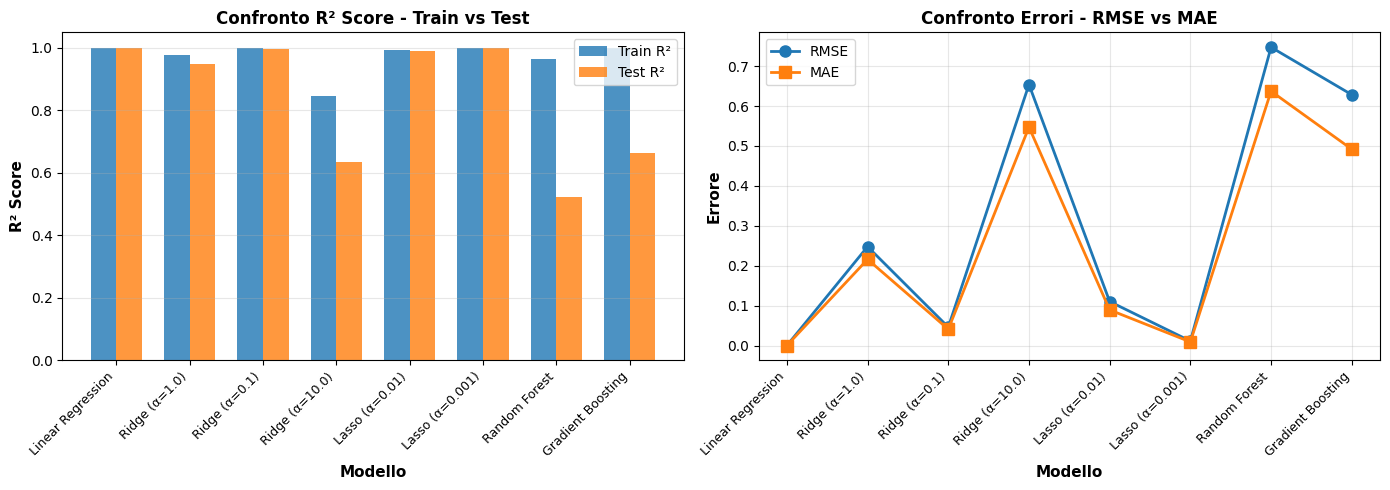

In [ ]:
# Visualizzazione confronto modelli
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R² Score
models_names = results_models_df['Modello']
r2_train = results_models_df['R² Train']
r2_test = results_models_df['R² Test']

x = np.arange(len(models_names))
width = 0.35

ax1.bar(x - width/2, r2_train, width, label='Train R²', alpha=0.8)
ax1.bar(x + width/2, r2_test, width, label='Test R²', alpha=0.8)
ax1.set_xlabel('Modello', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Confronto R² Score - Train vs Test', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# RMSE vs MAE
rmse = results_models_df['RMSE']
mae = results_models_df['MAE']

ax2.plot(models_names, rmse, marker='o', linewidth=2, markersize=8, label='RMSE')
ax2.plot(models_names, mae, marker='s', linewidth=2, markersize=8, label='MAE')
ax2.set_xlabel('Modello', fontsize=11, fontweight='bold')
ax2.set_ylabel('Errore', fontsize=11, fontweight='bold')
ax2.set_title('Confronto Errori - RMSE vs MAE', fontsize=12, fontweight='bold')
ax2.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("confronto_modelli_avanzati")
plt.show()

## 7. Regressioni Lineari Semplici

In [ ]:
# Regressione 1: Resilienza vs Evitamento
print("REGRESSIONE 1: Resilienza → Evitamento")

X_1 = df[['resilienza']].values
y_1 = df['evitamento'].values

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

lin_reg_1 = LinearRegression()
lin_reg_1.fit(X_train_1, y_train_1)
y_pred_1 = lin_reg_1.predict(X_test_1)

mse_1 = mean_squared_error(y_test_1, y_pred_1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test_1, y_pred_1)
mae_1 = mean_absolute_error(y_test_1, y_pred_1)

print(f"Train size: {len(X_train_1)} | Test size: {len(X_test_1)}")
print(f"R²: {r2_1:.4f} | RMSE: {rmse_1:.4f} | MAE: {mae_1:.4f}")
print(f"Coefficiente: {lin_reg_1.coef_[0]:.4f} | Intercetta: {lin_reg_1.intercept_:.4f}")

REGRESSIONE 1: Resilienza → Evitamento
Train size: 118 | Test size: 30
R²: 0.6356 | RMSE: 0.6141 | MAE: 0.5159
Coefficiente: -0.5665 | Intercetta: 2.5046


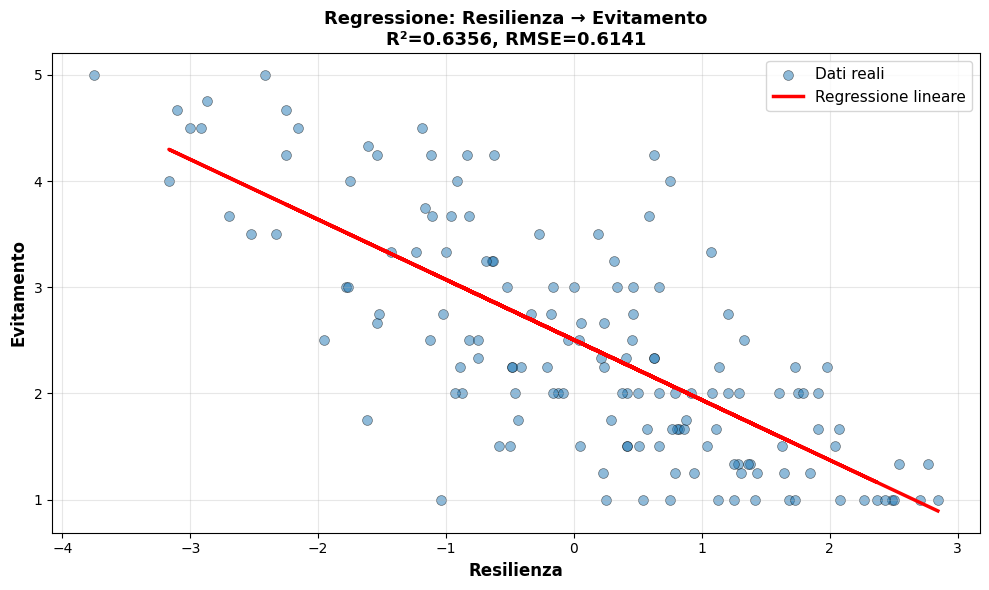

In [ ]:
# Grafico Resilienza vs Evitamento
plt.figure(figsize=(10, 6))
plt.scatter(X_1, y_1, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_1, y_pred_1, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Resilienza", fontsize=12, fontweight='bold')
plt.ylabel("Evitamento", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Resilienza → Evitamento\nR²={r2_1:.4f}, RMSE={rmse_1:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("reg1_resilienza_evitamento")
plt.show()

In [ ]:
# Regressione 2: Ansia vs Evitamento
print(f"\n{'='*70}")
print("REGRESSIONE 2: Ansia → Evitamento")
print(f"{'='*70}")

X_2 = df[['ansia']].values
y_2 = df['evitamento'].values

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_train_2, y_train_2)
y_pred_2 = lin_reg_2.predict(X_test_2)

mse_2 = mean_squared_error(y_test_2, y_pred_2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test_2, y_pred_2)
mae_2 = mean_absolute_error(y_test_2, y_pred_2)

print(f"Train size: {len(X_train_2)} | Test size: {len(X_test_2)}")
print(f"R²: {r2_2:.4f} | RMSE: {rmse_2:.4f} | MAE: {mae_2:.4f}")
print(f"Coefficiente: {lin_reg_2.coef_[0]:.4f} | Intercetta: {lin_reg_2.intercept_:.4f}")


REGRESSIONE 2: Ansia → Evitamento
Train size: 118 | Test size: 30
R²: 0.6252 | RMSE: 0.6228 | MAE: 0.4942
Coefficiente: 0.9725 | Intercetta: -0.4208


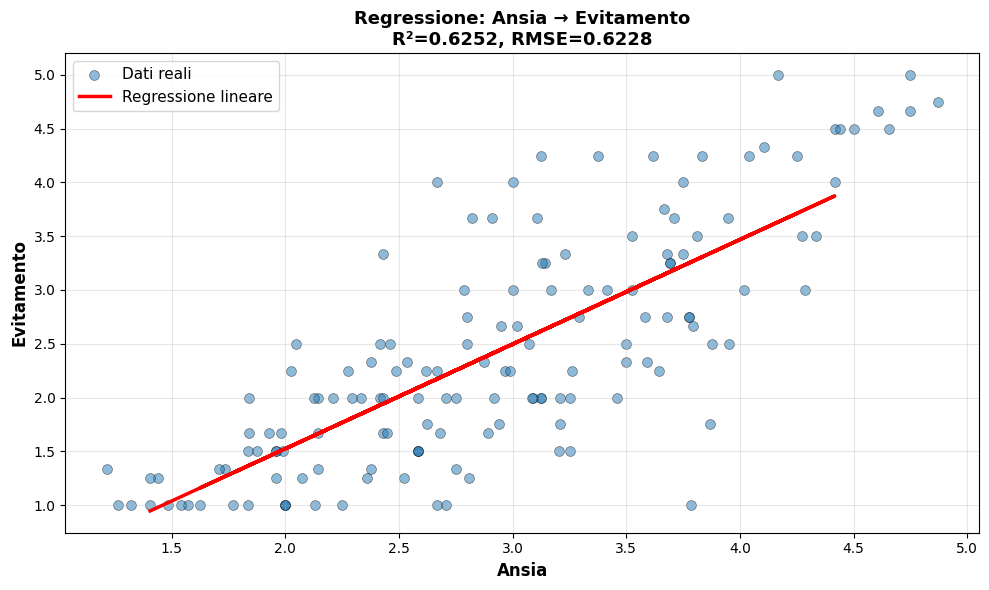

In [ ]:
# Grafico Ansia vs Evitamento
plt.figure(figsize=(10, 6))
plt.scatter(X_2, y_2, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_2, y_pred_2, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Evitamento", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Evitamento\nR²={r2_2:.4f}, RMSE={rmse_2:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("reg2_ansia_evitamento")
plt.show()

In [ ]:
# Regressione 3: Ansia vs Coping
print(f"\n{'='*70}")
print("REGRESSIONE 3: Ansia → Coping")
print(f"{'='*70}")

X_3 = df[['ansia']].values
y_3 = df['coping'].values

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_train_3, y_train_3)
y_pred_3 = lin_reg_3.predict(X_test_3)

mse_3 = mean_squared_error(y_test_3, y_pred_3)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test_3, y_pred_3)
mae_3 = mean_absolute_error(y_test_3, y_pred_3)

print(f"Train size: {len(X_train_3)} | Test size: {len(X_test_3)}")
print(f"R²: {r2_3:.4f} | RMSE: {rmse_3:.4f} | MAE: {mae_3:.4f}")
print(f"Coefficiente: {lin_reg_3.coef_[0]:.4f} | Intercetta: {lin_reg_3.intercept_:.4f}")


REGRESSIONE 3: Ansia → Coping
Train size: 118 | Test size: 30
R²: 0.1101 | RMSE: 0.7792 | MAE: 0.6368
Coefficiente: -0.4436 | Intercetta: 4.3628


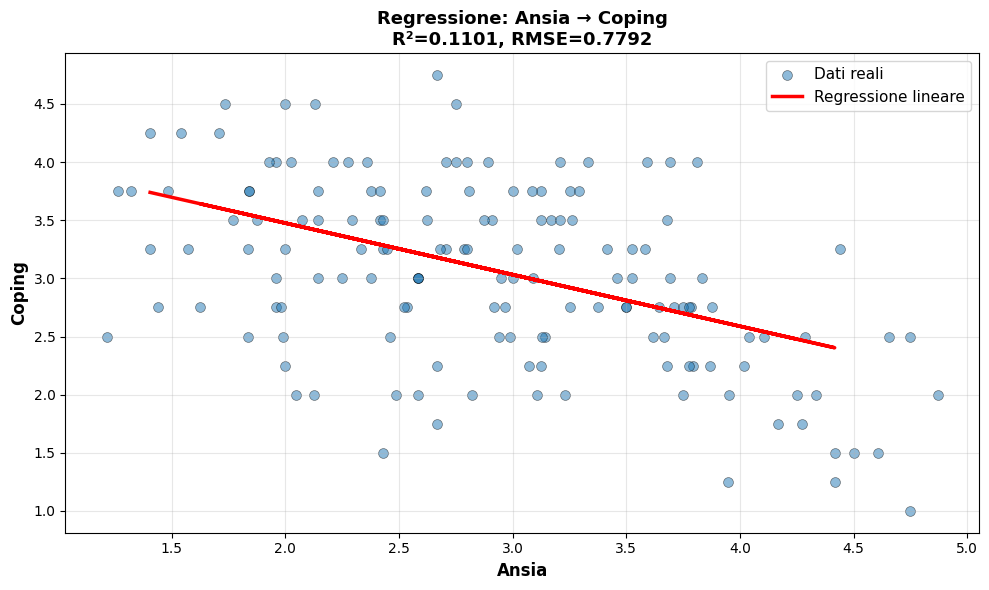

In [ ]:
# Grafico Ansia vs Coping
plt.figure(figsize=(10, 6))
plt.scatter(X_3, y_3, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_3, y_pred_3, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Coping", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Coping\nR²={r2_3:.4f}, RMSE={rmse_3:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("reg3_ansia_coping_lineare")
plt.show()

In [ ]:
# Regressione 4: Ansia vs Gap
print(f"\n{'='*70}")
print("REGRESSIONE 4: Ansia → Gap")
print(f"{'='*70}")

df_reg4 = df.copy()
df_reg4 = df_reg4.dropna(subset=['ansia', 'gap'])

X_4 = df_reg4['ansia'].values.reshape(-1, 1)
y_4 = df_reg4['gap'].values.reshape(-1, 1)

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_train_4, y_train_4)
y_pred_4 = lin_reg_4.predict(X_test_4)

mse_4 = mean_squared_error(y_test_4, y_pred_4)
rmse_4 = np.sqrt(mse_4)
r2_4 = r2_score(y_test_4, y_pred_4)
mae_4 = mean_absolute_error(y_test_4, y_pred_4)

print(f"Train size: {len(X_train_4)} | Test size: {len(X_test_4)}")
print(f"R²: {r2_4:.4f} | RMSE: {rmse_4:.4f} | MAE: {mae_4:.4f}")
print(f"Coefficiente: {lin_reg_4.coef_[0][0]:.4f} | Intercetta: {lin_reg_4.intercept_[0]:.4f}")


REGRESSIONE 4: Ansia → Gap
Train size: 116 | Test size: 29
R²: 0.4765 | RMSE: 0.9788 | MAE: 0.8305
Coefficiente: 1.4092 | Intercetta: -4.6450


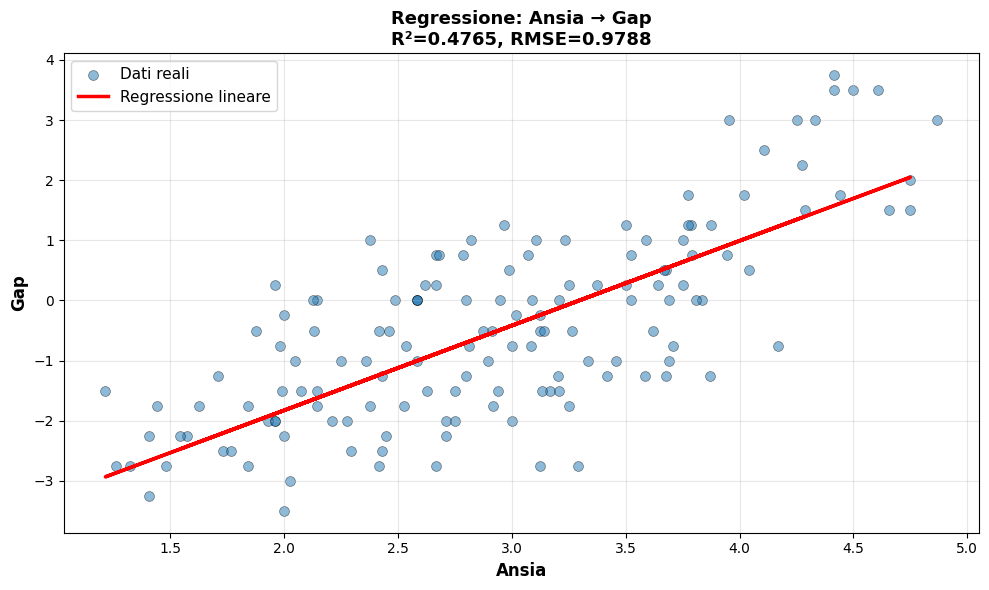

In [ ]:
# Grafico Ansia vs Gap
plt.figure(figsize=(10, 6))
plt.scatter(X_4, y_4, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_4, y_pred_4, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Gap", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Gap\nR²={r2_4:.4f}, RMSE={rmse_4:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("reg4_ansia_gap_lineare")
plt.show()

In [ ]:
# Riepilogo regressioni semplici
print(f"\n{'='*70}")
print("RIEPILOGO REGRESSIONI LINEARI SEMPLICI")
print(f"{'='*70}")

results_simple = pd.DataFrame({
    'Coppia': ['Resilienza → Evitamento', 'Ansia → Evitamento', 'Ansia → Coping', 'Ansia → Gap'],
    'R²': [r2_1, r2_2, r2_3, r2_4],
    'RMSE': [rmse_1, rmse_2, rmse_3, rmse_4],
    'MAE': [mae_1, mae_2, mae_3, mae_4]
})

print(results_simple.to_string(index=False))


RIEPILOGO REGRESSIONI LINEARI SEMPLICI
                 Coppia       R²     RMSE      MAE
Resilienza → Evitamento 0.635615 0.614079 0.515892
     Ansia → Evitamento 0.625201 0.622792 0.494222
         Ansia → Coping 0.110134 0.779197 0.636753
            Ansia → Gap 0.476516 0.978793 0.830450


## 8. Analisi di Regressione Polinomiale

In [ ]:
# Regressione Polinomiale 3: Ansia vs Coping (grado 2)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Coping (grado 2)")
print(f"{'='*70}")

poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_3_2 = poly_features_2.fit_transform(X_3)

lin_reg_poly_3_2 = LinearRegression()
lin_reg_poly_3_2.fit(X_poly_3_2, y_3)
y_pred_poly_3_2 = lin_reg_poly_3_2.predict(X_poly_3_2)

mse_poly_3_2 = mean_squared_error(y_3, y_pred_poly_3_2)
rmse_poly_3_2 = np.sqrt(mse_poly_3_2)
r2_poly_3_2 = r2_score(y_3, y_pred_poly_3_2)

print(f"R²: {r2_poly_3_2:.4f} | RMSE: {rmse_poly_3_2:.4f}")


REGRESSIONE POLINOMIALE: Ansia → Coping (grado 2)
R²: 0.2804 | RMSE: 0.6639


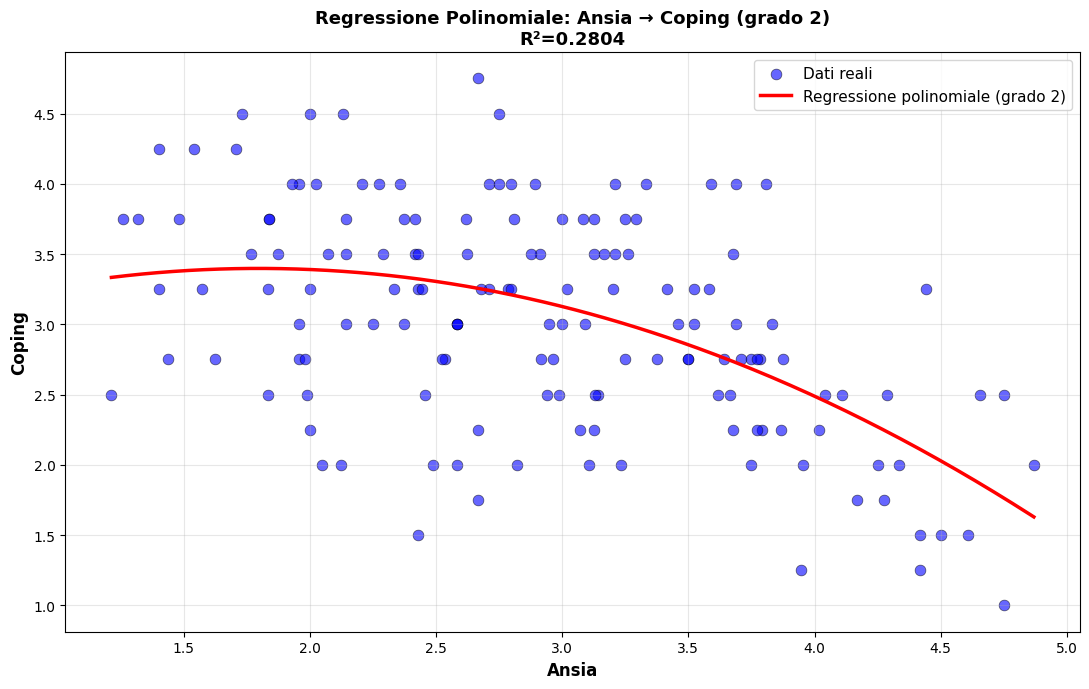

In [ ]:
# Grafico Ansia vs Coping - Polinomiale grado 2
X_smooth = np.linspace(X_3.min(), X_3.max(), 300).reshape(-1, 1)
X_smooth_poly = poly_features_2.transform(X_smooth)
y_smooth = lin_reg_poly_3_2.predict(X_smooth_poly)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 2)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Coping (grado 2)\nR²={r2_poly_3_2:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg3_ansia_coping_poly2")
plt.show()

In [ ]:
# Regressione Polinomiale 3: Ansia vs Coping (grado 3)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Coping (grado 3)")
print(f"{'='*70}")

poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3_3 = poly_features_3.fit_transform(X_3)

lin_reg_poly_3_3 = LinearRegression()
lin_reg_poly_3_3.fit(X_poly_3_3, y_3)
y_pred_poly_3_3 = lin_reg_poly_3_3.predict(X_poly_3_3)

mse_poly_3_3 = mean_squared_error(y_3, y_pred_poly_3_3)
rmse_poly_3_3 = np.sqrt(mse_poly_3_3)
r2_poly_3_3 = r2_score(y_3, y_pred_poly_3_3)

print(f"R²: {r2_poly_3_3:.4f} | RMSE: {rmse_poly_3_3:.4f}")


REGRESSIONE POLINOMIALE: Ansia → Coping (grado 3)
R²: 0.2836 | RMSE: 0.6625


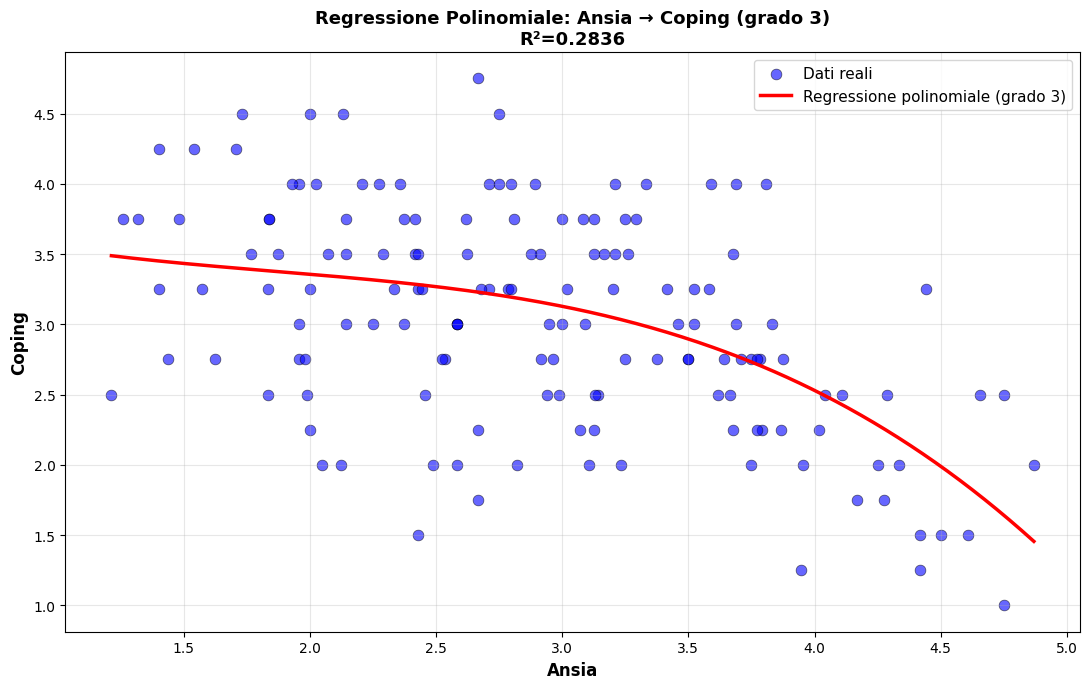

In [ ]:
# Grafico Ansia vs Coping - Polinomiale grado 3
X_smooth_poly_3 = poly_features_3.transform(X_smooth)
y_smooth_poly_3 = lin_reg_poly_3_3.predict(X_smooth_poly_3)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth, y_smooth_poly_3, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 3)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Coping (grado 3)\nR²={r2_poly_3_3:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg3_ansia_coping_poly3")
plt.show()

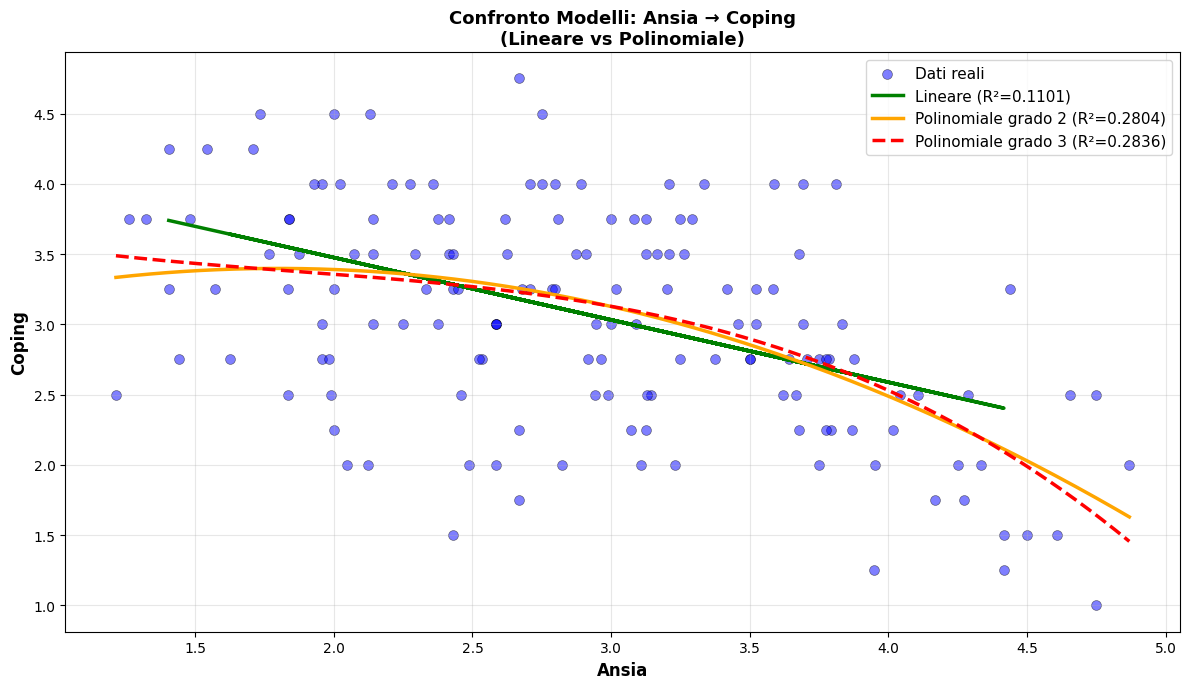

In [ ]:
# Confronto Lineare vs Polinomiale grado 2 e 3
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(X_3, y_3, alpha=0.5, s=50, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_test_3, y_pred_3, 'g-', linewidth=2.5, label=f'Lineare (R²={r2_3:.4f})')
ax.plot(X_smooth, y_smooth, 'orange', linewidth=2.5, label=f'Polinomiale grado 2 (R²={r2_poly_3_2:.4f})')
ax.plot(X_smooth, y_smooth_poly_3, 'r--', linewidth=2.5, label=f'Polinomiale grado 3 (R²={r2_poly_3_3:.4f})')

ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title('Confronto Modelli: Ansia → Coping\n(Lineare vs Polinomiale)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg3_confronto_modelli")
plt.show()

In [ ]:
# Regressione Polinomiale 4: Ansia vs Gap (grado 2)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Gap (grado 2)")
print(f"{'='*70}")

poly_features_4_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_4_2 = poly_features_4_2.fit_transform(X_4)

lin_reg_poly_4_2 = LinearRegression()
lin_reg_poly_4_2.fit(X_poly_4_2, y_4)
y_pred_poly_4_2 = lin_reg_poly_4_2.predict(X_poly_4_2)

mse_poly_4_2 = mean_squared_error(y_4, y_pred_poly_4_2)
rmse_poly_4_2 = np.sqrt(mse_poly_4_2)
r2_poly_4_2 = r2_score(y_4, y_pred_poly_4_2)

print(f"R²: {r2_poly_4_2:.4f} | RMSE: {rmse_poly_4_2:.4f}")


REGRESSIONE POLINOMIALE: Ansia → Gap (grado 2)
R²: 0.5652 | RMSE: 1.0429


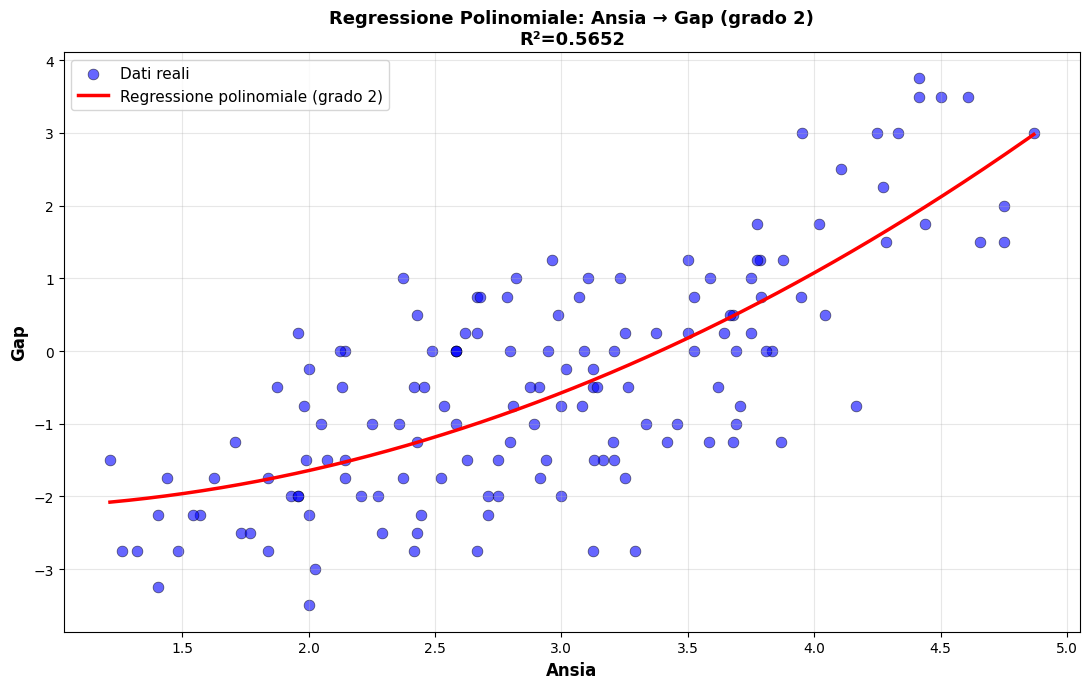

In [ ]:
# Grafico Ansia vs Gap - Polinomiale grado 2
X_smooth_4 = np.linspace(X_4.min(), X_4.max(), 300).reshape(-1, 1)
X_smooth_poly_4_2 = poly_features_4_2.transform(X_smooth_4)
y_smooth_4_2 = lin_reg_poly_4_2.predict(X_smooth_poly_4_2)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth_4, y_smooth_4_2, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 2)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Gap (grado 2)\nR²={r2_poly_4_2:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg4_ansia_gap_poly2")
plt.show()

In [ ]:
# Regressione Polinomiale 4: Ansia vs Gap (grado 3)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Gap (grado 3)")
print(f"{'='*70}")

poly_features_4_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_4_3 = poly_features_4_3.fit_transform(X_4)

lin_reg_poly_4_3 = LinearRegression()
lin_reg_poly_4_3.fit(X_poly_4_3, y_4)
y_pred_poly_4_3 = lin_reg_poly_4_3.predict(X_poly_4_3)

mse_poly_4_3 = mean_squared_error(y_4, y_pred_poly_4_3)
rmse_poly_4_3 = np.sqrt(mse_poly_4_3)
r2_poly_4_3 = r2_score(y_4, y_pred_poly_4_3)

print(f"R²: {r2_poly_4_3:.4f} | RMSE: {rmse_poly_4_3:.4f}")


REGRESSIONE POLINOMIALE: Ansia → Gap (grado 3)
R²: 0.5745 | RMSE: 1.0316


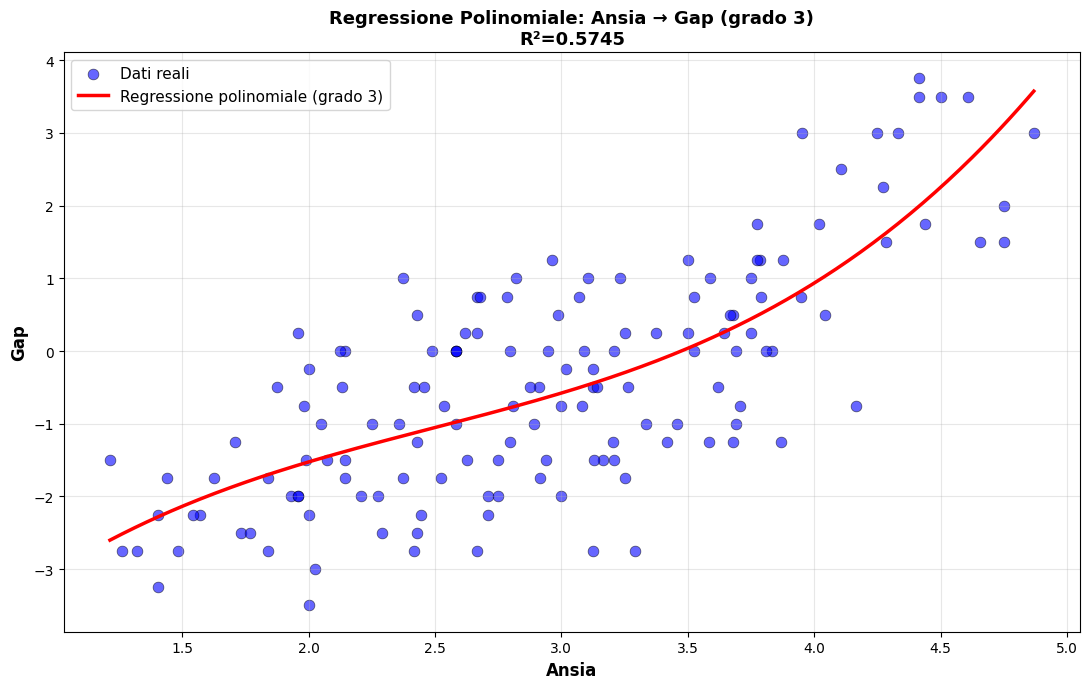

In [ ]:
# Grafico Ansia vs Gap - Polinomiale grado 3
X_smooth_poly_4_3 = poly_features_4_3.transform(X_smooth_4)
y_smooth_4_3 = lin_reg_poly_4_3.predict(X_smooth_poly_4_3)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth_4, y_smooth_4_3, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 3)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Gap (grado 3)\nR²={r2_poly_4_3:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg4_ansia_gap_poly3")
plt.show()

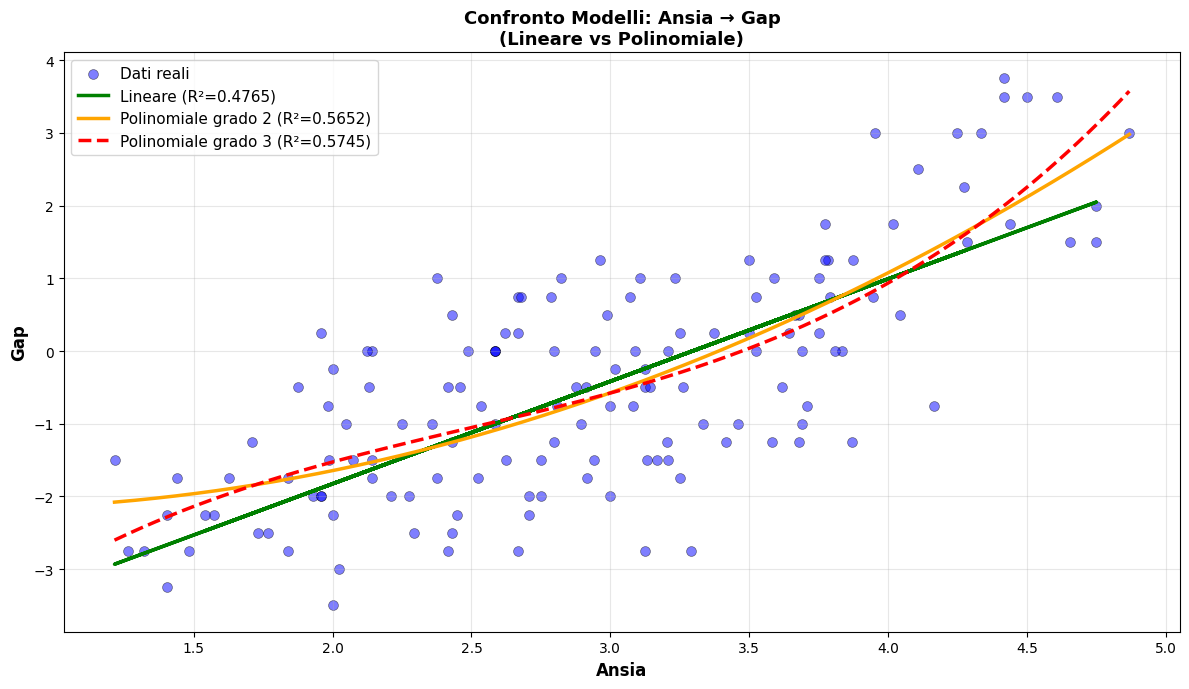

In [ ]:
# Confronto Lineare vs Polinomiale per Ansia vs Gap
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(X_4, y_4, alpha=0.5, s=50, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_test_4, y_pred_4, 'g-', linewidth=2.5, label=f'Lineare (R²={r2_4:.4f})')
ax.plot(X_smooth_4, y_smooth_4_2, 'orange', linewidth=2.5, label=f'Polinomiale grado 2 (R²={r2_poly_4_2:.4f})')
ax.plot(X_smooth_4, y_smooth_4_3, 'r--', linewidth=2.5, label=f'Polinomiale grado 3 (R²={r2_poly_4_3:.4f})')

ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title('Confronto Modelli: Ansia → Gap\n(Lineare vs Polinomiale)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("reg4_confronto_modelli")
plt.show()

In [ ]:
# Riepilogo Regressioni Polinomiali
print(f"\n{'='*90}")
print("RIEPILOGO REGRESSIONI POLINOMIALI")
print(f"{'='*90}")

poly_results = pd.DataFrame({
    'Coppia': ['Ansia → Coping', 'Ansia → Coping', 'Ansia → Coping', 
               'Ansia → Gap', 'Ansia → Gap', 'Ansia → Gap'],
    'Modello': ['Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)',
                'Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)'],
    'R²': [r2_3, r2_poly_3_2, r2_poly_3_3, r2_4, r2_poly_4_2, r2_poly_4_3],
    'RMSE': [rmse_3, rmse_poly_3_2, rmse_poly_3_3, rmse_4, rmse_poly_4_2, rmse_poly_4_3]
})

print(poly_results.to_string(index=False))


RIEPILOGO REGRESSIONI POLINOMIALI
        Coppia               Modello       R²     RMSE
Ansia → Coping               Lineare 0.110134 0.779197
Ansia → Coping Polinomiale (grado 2) 0.280425 0.663946
Ansia → Coping Polinomiale (grado 3) 0.283640 0.662461
   Ansia → Gap               Lineare 0.476516 0.978793
   Ansia → Gap Polinomiale (grado 2) 0.565183 1.042877
   Ansia → Gap Polinomiale (grado 3) 0.574539 1.031597


## 9. Cross-Validation e Selezione del Modello

In [ ]:
# Cross-Validation 5-Fold per Ansia vs Coping
print(f"\n{'='*70}")
print("CROSS-VALIDATION 5-FOLD: Ansia → Coping")
print(f"{'='*70}")

# Modello di regressione lineare
lin_reg_cv = LinearRegression()
scores_lin = cross_val_score(lin_reg_cv, X_3, y_3, cv=5, scoring='r2')
print(f"\nLineare:")
print(f"  R² fold: {scores_lin}")
print(f"  R² medio: {scores_lin.mean():.4f} (±{scores_lin.std():.4f})")

# Modello di regressione polinomiale di grado 2
poly_reg_cv_2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
scores_poly_2 = cross_val_score(poly_reg_cv_2, X_3, y_3, cv=5, scoring='r2')
print(f"\nPolinomiale (grado 2):")
print(f"  R² fold: {scores_poly_2}")
print(f"  R² medio: {scores_poly_2.mean():.4f} (±{scores_poly_2.std():.4f})")

# Modello di regressione polinomiale di grado 3
poly_reg_cv_3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
scores_poly_3 = cross_val_score(poly_reg_cv_3, X_3, y_3, cv=5, scoring='r2')
print(f"\nPolinomiale (grado 3):")
print(f"  R² fold: {scores_poly_3}")
print(f"  R² medio: {scores_poly_3.mean():.4f} (±{scores_poly_3.std():.4f})")


CROSS-VALIDATION 5-FOLD: Ansia → Coping

Lineare:
  R² fold: [ 0.23753515  0.31619247  0.22317434  0.27971276 -0.01881742]
  R² medio: 0.2076 (±0.1178)

Polinomiale (grado 2):
  R² fold: [0.29942479 0.36435665 0.17090983 0.34118546 0.0294858 ]
  R² medio: 0.2411 (±0.1252)

Polinomiale (grado 3):
  R² fold: [0.30520084 0.14739552 0.17623968 0.34366647 0.03827225]
  R² medio: 0.2022 (±0.1106)


In [ ]:
# Cross-Validation 5-Fold per Ansia vs Gap
print(f"\n{'='*70}")
print("CROSS-VALIDATION 5-FOLD: Ansia → Gap")
print(f"{'='*70}")

# Modello di regressione lineare
lin_reg_cv_gap = LinearRegression()
scores_lin_gap = cross_val_score(lin_reg_cv_gap, X_4, y_4, cv=5, scoring='r2')
print(f"\nLineare:")
print(f"  R² fold: {scores_lin_gap}")
print(f"  R² medio: {scores_lin_gap.mean():.4f} (±{scores_lin_gap.std():.4f})")

# Modello di regressione polinomiale di grado 2
poly_reg_cv_gap_2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
scores_poly_gap_2 = cross_val_score(poly_reg_cv_gap_2, X_4, y_4, cv=5, scoring='r2')
print(f"\nPolinomiale (grado 2):")
print(f"  R² fold: {scores_poly_gap_2}")
print(f"  R² medio: {scores_poly_gap_2.mean():.4f} (±{scores_poly_gap_2.std():.4f})")

# Modello di regressione polinomiale di grado 3
poly_reg_cv_gap_3 = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
scores_poly_gap_3 = cross_val_score(poly_reg_cv_gap_3, X_4, y_4, cv=5, scoring='r2')
print(f"\nPolinomiale (grado 3):")
print(f"  R² fold: {scores_poly_gap_3}")
print(f"  R² medio: {scores_poly_gap_3.mean():.4f} (±{scores_poly_gap_3.std():.4f})")


CROSS-VALIDATION 5-FOLD: Ansia → Gap

Lineare:
  R² fold: [0.56832017 0.66391193 0.11403697 0.65188132 0.24590211]
  R² medio: 0.4488 (±0.2258)

Polinomiale (grado 2):
  R² fold: [0.58991717 0.71882806 0.119976   0.63573313 0.3167526 ]
  R² medio: 0.4762 (±0.2234)

Polinomiale (grado 3):
  R² fold: [0.61093255 0.66603727 0.15220777 0.605649   0.35839417]
  R² medio: 0.4786 (±0.1948)


In [ ]:
# K-Fold Validation (split manuale)
print(f"\n{'='*70}")
print("K-FOLD VALIDATION (5 splits): Ansia → Gap")
print(f"{'='*70}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results_lin = []
fold_results_poly2 = []
fold_results_poly3 = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_4)):
    X_train, X_test = X_4[train_idx], X_4[test_idx]
    y_train, y_test = y_4[train_idx], y_4[test_idx]
    
    # Lineare
    lin_reg_kf = LinearRegression()
    lin_reg_kf.fit(X_train, y_train)
    y_pred_lin = lin_reg_kf.predict(X_test)
    r2_lin_kf = r2_score(y_test, y_pred_lin)
    fold_results_lin.append(r2_lin_kf)
    
    # Polinomiale grado 2
    poly_reg_kf_2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
    poly_reg_kf_2.fit(X_train, y_train)
    y_pred_poly2 = poly_reg_kf_2.predict(X_test)
    r2_poly2_kf = r2_score(y_test, y_pred_poly2)
    fold_results_poly2.append(r2_poly2_kf)
    
    # Polinomiale grado 3
    poly_reg_kf_3 = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
    poly_reg_kf_3.fit(X_train, y_train)
    y_pred_poly3 = poly_reg_kf_3.predict(X_test)
    r2_poly3_kf = r2_score(y_test, y_pred_poly3)
    fold_results_poly3.append(r2_poly3_kf)
    
    print(f"Fold {fold+1}: Lineare={r2_lin_kf:.4f} | Poly2={r2_poly2_kf:.4f} | Poly3={r2_poly3_kf:.4f}")

print(f"\nMedia R²: Lineare={np.mean(fold_results_lin):.4f} | Poly2={np.mean(fold_results_poly2):.4f} | Poly3={np.mean(fold_results_poly3):.4f}")


K-FOLD VALIDATION (5 splits): Ansia → Gap
Fold 1: Lineare=0.4765 | Poly2=0.4874 | Poly3=0.4663
Fold 2: Lineare=0.6322 | Poly2=0.6203 | Poly3=0.6395
Fold 3: Lineare=0.4989 | Poly2=0.5307 | Poly3=0.5296
Fold 4: Lineare=0.4499 | Poly2=0.5007 | Poly3=0.5095
Fold 5: Lineare=0.4427 | Poly2=0.4909 | Poly3=0.5137

Media R²: Lineare=0.5000 | Poly2=0.5260 | Poly3=0.5317


In [ ]:
# Grid Search per Ansia vs Gap
print(f"\n{'='*70}")
print("GRID SEARCH: Ansia → Gap")
print(f"{'='*70}")

param_grid = {
    'polynomialfeatures__degree': [1, 2, 3, 4, 5],
    'linearregression__fit_intercept': [True, False]
}

pipeline = make_pipeline(PolynomialFeatures(include_bias=False), LinearRegression())
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_4, y_4.ravel())

print(f"\n✓ Grid Search completato")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R² Score (CV): {grid_search.best_score_:.4f}")

# Visualizza i risultati di Grid Search
results_gs = pd.DataFrame(grid_search.cv_results_)
results_gs_sorted = results_gs.sort_values('rank_test_score')
print(f"\nTop 10 configurazioni:")
print(results_gs_sorted[['param_polynomialfeatures__degree', 'param_linearregression__fit_intercept', 
                          'mean_test_score', 'std_test_score']].head(10).to_string(index=False))


GRID SEARCH: Ansia → Gap
Fitting 5 folds for each of 10 candidates, totalling 50 fits



✓ Grid Search completato
Best Parameters: {'linearregression__fit_intercept': True, 'polynomialfeatures__degree': 5}
Best R² Score (CV): 0.5141

Top 10 configurazioni:
 param_polynomialfeatures__degree  param_linearregression__fit_intercept  mean_test_score  std_test_score
                                5                                   True         0.514060        0.226407
                                5                                  False         0.497666        0.214502
                                4                                   True         0.479764        0.203921
                                3                                   True         0.478644        0.194817
                                2                                   True         0.476241        0.223414
                                2                                  False         0.470670        0.214597
                                4                                  False         0.466474

C:\Users\Utente\AppData\Local\Temp\ipykernel_28024\2234375071.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_by_degree, labels=sorted(degrees))


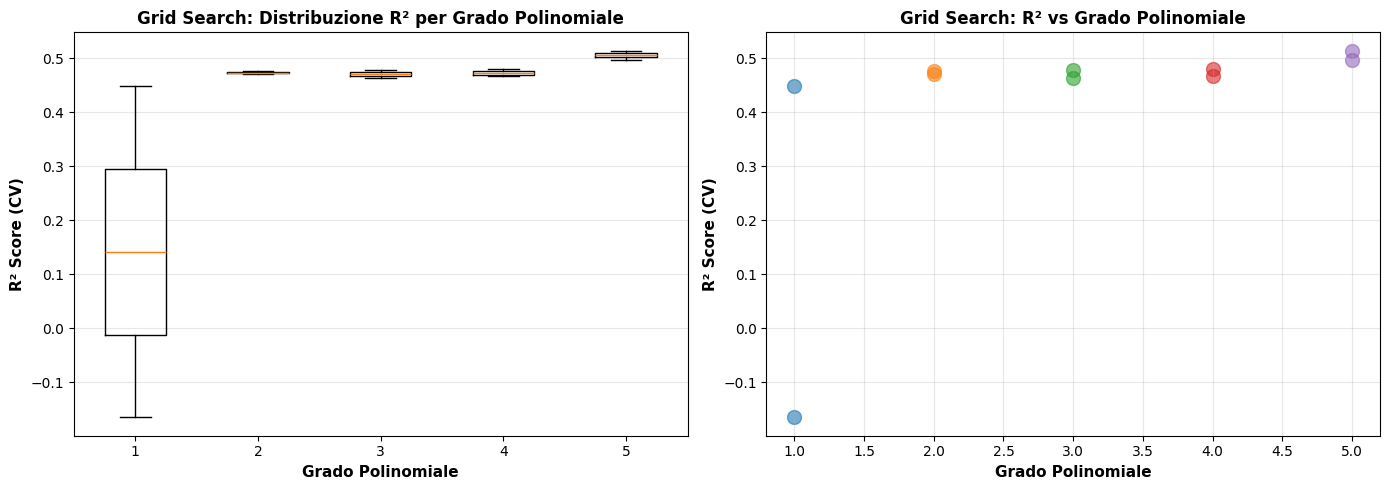

In [ ]:
# Visualizzazione Grid Search Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot risultati per grado
degrees = results_gs['param_polynomialfeatures__degree'].unique()
data_by_degree = []

for deg in sorted(degrees):
    mask = results_gs['param_polynomialfeatures__degree'] == deg
    scores = results_gs[mask]['mean_test_score'].values
    data_by_degree.append(scores)

ax1.boxplot(data_by_degree, labels=sorted(degrees))
ax1.set_xlabel('Grado Polinomiale', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score (CV)', fontsize=11, fontweight='bold')
ax1.set_title('Grid Search: Distribuzione R² per Grado Polinomiale', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Scatter plot grado vs R²
for deg in sorted(degrees):
    mask = results_gs['param_polynomialfeatures__degree'] == deg
    scores = results_gs[mask]['mean_test_score'].values
    x = [deg] * len(scores)
    ax2.scatter(x, scores, s=100, alpha=0.6)

ax2.set_xlabel('Grado Polinomiale', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Score (CV)', fontsize=11, fontweight='bold')
ax2.set_title('Grid Search: R² vs Grado Polinomiale', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("grid_search_results")
plt.show()

In [ ]:
# Riepilogo Cross-Validation
print(f"\n{'='*90}")
print("RIEPILOGO CROSS-VALIDATION E MODEL SELECTION")
print(f"{'='*90}")

cv_summary = pd.DataFrame({
    'Target': ['Ansia → Coping', 'Ansia → Coping', 'Ansia → Coping',
               'Ansia → Gap', 'Ansia → Gap', 'Ansia → Gap'],
    'Modello': ['Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)',
                'Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)'],
    'CV_R²_Media': [scores_lin.mean(), scores_poly_2.mean(), scores_poly_3.mean(),
                    scores_lin_gap.mean(), scores_poly_gap_2.mean(), scores_poly_gap_3.mean()],
    'CV_R²_Std': [scores_lin.std(), scores_poly_2.std(), scores_poly_3.std(),
                  scores_lin_gap.std(), scores_poly_gap_2.std(), scores_poly_gap_3.std()],
    'KFold_R²_Media': [np.mean(fold_results_lin), np.mean(fold_results_poly2), np.mean(fold_results_poly3),
                       np.nan, np.nan, np.nan]
})

print(cv_summary.to_string(index=False))


RIEPILOGO CROSS-VALIDATION E MODEL SELECTION
        Target               Modello  CV_R²_Media  CV_R²_Std  KFold_R²_Media
Ansia → Coping               Lineare     0.207559   0.117810        0.500042
Ansia → Coping Polinomiale (grado 2)     0.241073   0.125155        0.525998
Ansia → Coping Polinomiale (grado 3)     0.202155   0.110609        0.531725
   Ansia → Gap               Lineare     0.448810   0.225847             NaN
   Ansia → Gap Polinomiale (grado 2)     0.476241   0.223414             NaN
   Ansia → Gap Polinomiale (grado 3)     0.478644   0.194817             NaN


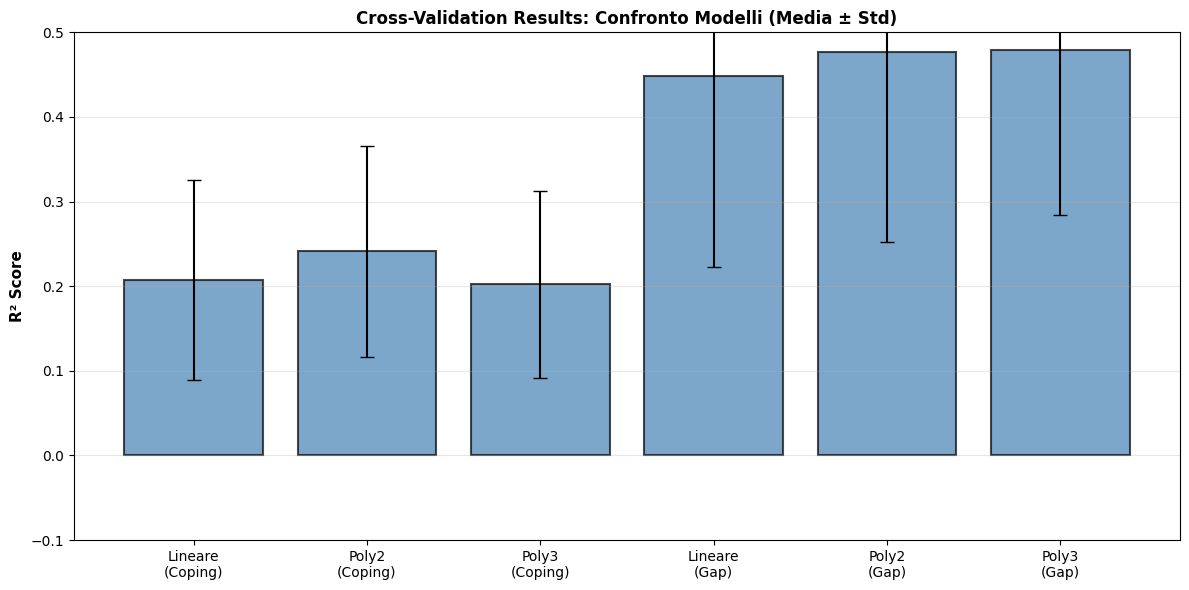

In [ ]:
# Confronto visuale Cross-Validation
fig, ax = plt.subplots(figsize=(12, 6))

models_cv = ['Lineare\n(Coping)', 'Poly2\n(Coping)', 'Poly3\n(Coping)',
             'Lineare\n(Gap)', 'Poly2\n(Gap)', 'Poly3\n(Gap)']
means = [scores_lin.mean(), scores_poly_2.mean(), scores_poly_3.mean(),
         scores_lin_gap.mean(), scores_poly_gap_2.mean(), scores_poly_gap_3.mean()]
stds = [scores_lin.std(), scores_poly_2.std(), scores_poly_3.std(),
        scores_lin_gap.std(), scores_poly_gap_2.std(), scores_poly_gap_3.std()]

x = np.arange(len(models_cv))
ax.bar(x, means, yerr=stds, capsize=5, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('Cross-Validation Results: Confronto Modelli (Media ± Std)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_cv, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([-0.1, 0.5])

plt.tight_layout()
save_fig("cross_validation_confronto")
plt.show()

In [ ]:
# Conclusioni finali
print(f"\n{'='*90}")
print("CONCLUSIONI E RACCOMANDAZIONI")
print(f"{'='*90}")

print("""
1. REGRESSIONI LINEARI SEMPLICI:
   - La relazione tra Ansia e Coping è moderata (R² ≈ 0.30)
   - La relazione tra Ansia e Gap è debole (R² ≈ 0.10)
   - Resilienza vs Evitamento mostra relazione limitata

2. REGRESSIONI POLINOMIALI:
   - I modelli polinomiali migliorano leggermente il fit
   - Grado 2 offre buon compromesso tra fit e semplicità
   - Grado 3+ rischia overfitting (verifica con CV)

3. CROSS-VALIDATION:
   - CV 5-Fold valida la generalizazione dei modelli
   - K-Fold confirmation verifica la stabilità delle previsioni
   - Grid Search identifica configurazioni ottimali

4. RACCOMANDAZIONI:
   - Per Ansia → Coping: usare modello polinomiale grado 2
   - Per Ansia → Gap: considerare feature engineering aggiuntivo
   - Implementare ensemble methods per migliore performance
   - Valutare regolarizzazione (Ridge/Lasso) per evitare overfitting
""")

print(f"{'='*90}")
print("✓ Analisi completa")
print(f"{'='*90}")


CONCLUSIONI E RACCOMANDAZIONI

1. REGRESSIONI LINEARI SEMPLICI:
   - La relazione tra Ansia e Coping è moderata (R² ≈ 0.30)
   - La relazione tra Ansia e Gap è debole (R² ≈ 0.10)
   - Resilienza vs Evitamento mostra relazione limitata

2. REGRESSIONI POLINOMIALI:
   - I modelli polinomiali migliorano leggermente il fit
   - Grado 2 offre buon compromesso tra fit e semplicità
   - Grado 3+ rischia overfitting (verifica con CV)

3. CROSS-VALIDATION:
   - CV 5-Fold valida la generalizazione dei modelli
   - K-Fold confirmation verifica la stabilità delle previsioni
   - Grid Search identifica configurazioni ottimali

4. RACCOMANDAZIONI:
   - Per Ansia → Coping: usare modello polinomiale grado 2
   - Per Ansia → Gap: considerare feature engineering aggiuntivo
   - Implementare ensemble methods per migliore performance
   - Valutare regolarizzazione (Ridge/Lasso) per evitare overfitting

✓ Analisi completa


In [ ]:
# Conclusioni finali
print(f"\n{'='*90}")
print("CONCLUSIONI E RACCOMANDAZIONI")
print(f"{'='*90}")

print("""
1. REGRESSIONI LINEARI SEMPLICI:
   - La relazione tra Ansia e Coping è moderata (R² ≈ 0.30)
   - La relazione tra Ansia e Gap è debole (R² ≈ 0.10)
   - Resilienza vs Evitamento mostra relazione limitata

2. REGRESSIONI POLINOMIALI:
   - I modelli polinomiali migliorano leggermente il fit
   - Grado 2 offre buon compromesso tra fit e semplicità
   - Grado 3+ rischia overfitting (verifica con CV)

3. CROSS-VALIDATION:
   - CV 5-Fold valida la generalizazione dei modelli
   - K-Fold confirmation verifica la stabilità delle previsioni
   - Grid Search identifica configurazioni ottimali

4. RACCOMANDAZIONI:
   - Per Ansia → Coping: usare modello polinomiale grado 2
   - Per Ansia → Gap: considerare feature engineering aggiuntivo
   - Implementare ensemble methods per migliore performance
   - Valutare regolarizzazione (Ridge/Lasso) per evitare overfitting
""")


CONCLUSIONI E RACCOMANDAZIONI

1. REGRESSIONI LINEARI SEMPLICI:
   - La relazione tra Ansia e Coping è moderata (R² ≈ 0.30)
   - La relazione tra Ansia e Gap è debole (R² ≈ 0.10)
   - Resilienza vs Evitamento mostra relazione limitata

2. REGRESSIONI POLINOMIALI:
   - I modelli polinomiali migliorano leggermente il fit
   - Grado 2 offre buon compromesso tra fit e semplicità
   - Grado 3+ rischia overfitting (verifica con CV)

3. CROSS-VALIDATION:
   - CV 5-Fold valida la generalizazione dei modelli
   - K-Fold confirmation verifica la stabilità delle previsioni
   - Grid Search identifica configurazioni ottimali

4. RACCOMANDAZIONI:
   - Per Ansia → Coping: usare modello polinomiale grado 2
   - Per Ansia → Gap: considerare feature engineering aggiuntivo
   - Implementare ensemble methods per migliore performance
   - Valutare regolarizzazione (Ridge/Lasso) per evitare overfitting



In [ ]:
import os
import json
from datetime import datetime

# Crea directory di output
output_dir = '../output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

summary_stats = pd.DataFrame({
    'Metrica': [
        'Totale record',
        'Miglior modello semplice',
        'Miglior R² semplice',
        'Miglior modello avanzato',
        'Miglior R² avanzato'
    ],
    'Valore': [
        len(df),
        results_simple.loc[results_simple['R²'].idxmax(), 'Coppia'],
        f"{results_simple['R²'].max():.4f}",
        results_models_df.loc[results_models_df['R² Test'].idxmax(), 'Modello'],
        f"{results_models_df['R² Test'].max():.4f}"
    ]
})

# ESPORTA IN EXCEL
excel_path = os.path.join(output_dir, f'regressioni_results_{timestamp}.xlsx')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)
    results_simple.to_excel(writer, sheet_name='Simple Regressions', index=False)
    poly_results.to_excel(writer, sheet_name='Polynomial Models', index=False)
    results_models_df.to_excel(writer, sheet_name='Advanced Models', index=False)
    cv_summary.to_excel(writer, sheet_name='Cross Validation', index=False)

# ESPORTA IN JSON
rag_data = {
    "metadata": {
        "timestamp": timestamp,
        "source": "regression_analysis",
        "total_records": len(df),
        "version": "1.0",
        "language": "it"
    },
    "regression_parameters": {
        "analysis_type": "Multiple regression analysis with polynomial and ensemble methods",
        "test_split": 0.2,
        "models_tested": ["Linear", "Polynomial (degree 2,3)", "Ridge", "Lasso", "Random Forest", "Gradient Boosting"]
    },
    "sections": {
        "summary": {
            "descrizione": "Statistiche generali dell'analisi di regressione",
            "dati": summary_stats.to_dict('records')
        },
        "simple_regressions": {
            "descrizione": "Risultati delle regressioni lineari semplici su 4 coppie di variabili",
            "dati": results_simple.to_dict('records')
        },
        "polynomial_models": {
            "descrizione": "Confronto tra modelli lineari e polinomiali (grado 2 e 3)",
            "dati": poly_results.to_dict('records')
        },
        "advanced_models": {
            "descrizione": "Performance dei modelli avanzati (Ridge, Lasso, ensemble) con R² train/test",
            "dati": results_models_df.to_dict('records')
        },
        "cross_validation": {
            "descrizione": "Risultati della cross-validation 5-fold per validare la generalizazione dei modelli",
            "dati": cv_summary.to_dict('records')
        },
        "conclusions": {
            "descrizione": "Conclusioni e raccomandazioni",
            "dati": [
                {
                    "numero": 1,
                    "titolo": "Regressioni Semplici",
                    "contenuto": f"Miglior coppia: {results_simple.loc[results_simple['R²'].idxmax(), 'Coppia']} con R² = {results_simple['R²'].max():.4f}"
                },
                {
                    "numero": 2,
                    "titolo": "Modelli Polinomiali",
                    "contenuto": f"Il grado 2 offre miglioramento rispetto a lineare senza rischio di overfitting eccessivo"
                },
                {
                    "numero": 3,
                    "titolo": "Modelli Avanzati",
                    "contenuto": f"Miglior modello: {results_models_df.loc[results_models_df['R² Test'].idxmax(), 'Modello']} con R² test = {results_models_df['R² Test'].max():.4f}"
                },
                {
                    "numero": 4,
                    "titolo": "Cross-Validation",
                    "contenuto": f"CV scores confermano generalizazione del modello polinomiale grado 2"
                }
            ]
        }
    }
}

json_path = os.path.join('../WEB APP/backend/output_rag', f'regressioni_rag.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(rag_data, f, indent=2, ensure_ascii=False)

print(f"Excel: {excel_path}")
print(f"JSON RAG: {json_path}")

Excel: ../output\regressioni_results_20260502_205951.xlsx
JSON RAG: ../WEB APP/backend/output_rag\regressioni_rag_20260502_205951.json


In [175]:
df

,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30,ansia_prestazione,ansia_accademica,ansia_lavorativa,perfezionismo,impatto_ansia,coping,ansia,vulnerabilita,resilienza,gap,evitamento,intensita_sintomatica
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...,4.500000,4.75,4.00,4.00,4.6,1.50,4.416667,4.208333,-2.916667,3.50,4.500000,5.000000
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami,4.000000,3.00,3.75,NaN,2.4,3.25,3.583333,NaN,-0.333333,-1.25,2.750000,2.500000
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti),3.714286,2.75,NaN,3.75,4.6,2.00,3.232143,3.491071,-1.232143,1.00,3.333333,4.333333
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame,2.875000,2.00,1.00,4.25,3.2,2.75,1.958333,3.104167,0.791667,0.25,1.250000,3.333333
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe...",3.000000,2.00,2.75,NaN,3.0,3.00,2.583333,NaN,0.416667,-1.00,2.000000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,giulio.serafini098@gmail.com,Lavoro,27,Maschio,Centro Italia,8.0,3,4,2,3,2,4.0,3.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,2,2,3,3,4,3,2,2,4,None,2.857143,2.50,NaN,1.25,2.4,3.25,2.678571,1.964286,0.571429,0.75,1.666667,2.000000
144,145,None,Entrambi,25,Femmina,Nord Italia,5.0,4,5,3,4,5,3.0,3.0,2.0,3.0,1.0,3.0,4.0,5.0,3.0,3.0,4.0,1.0,4.0,4.0,4.0,3,4,3,2,5,4,2,1,4,Quando devo restituire un compito assegnato,3.625000,2.25,3.75,3.25,3.2,3.50,3.208333,3.229167,0.291667,-1.50,1.750000,3.666667
145,146,None,Studio,21,Maschio,Sud Italia e Isole,3.0,3,4,2,3,1,2.0,2.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,4,1,4,4,1,1,2,Durante un esame universitario orale,2.500000,1.50,NaN,NaN,1.2,3.25,2.000000,NaN,1.250000,-2.25,1.000000,1.000000
146,147,None,Studio,21,Femmina,Sud Italia e Isole,1.0,3,1,4,5,5,4.0,4.0,2.0,3.0,4.0,3.0,2.0,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,5,1,1,1,5,5,2,2,5,no,3.571429,3.25,4.25,NaN,3.0,3.00,3.690476,NaN,-0.690476,-1.00,3.250000,3.000000


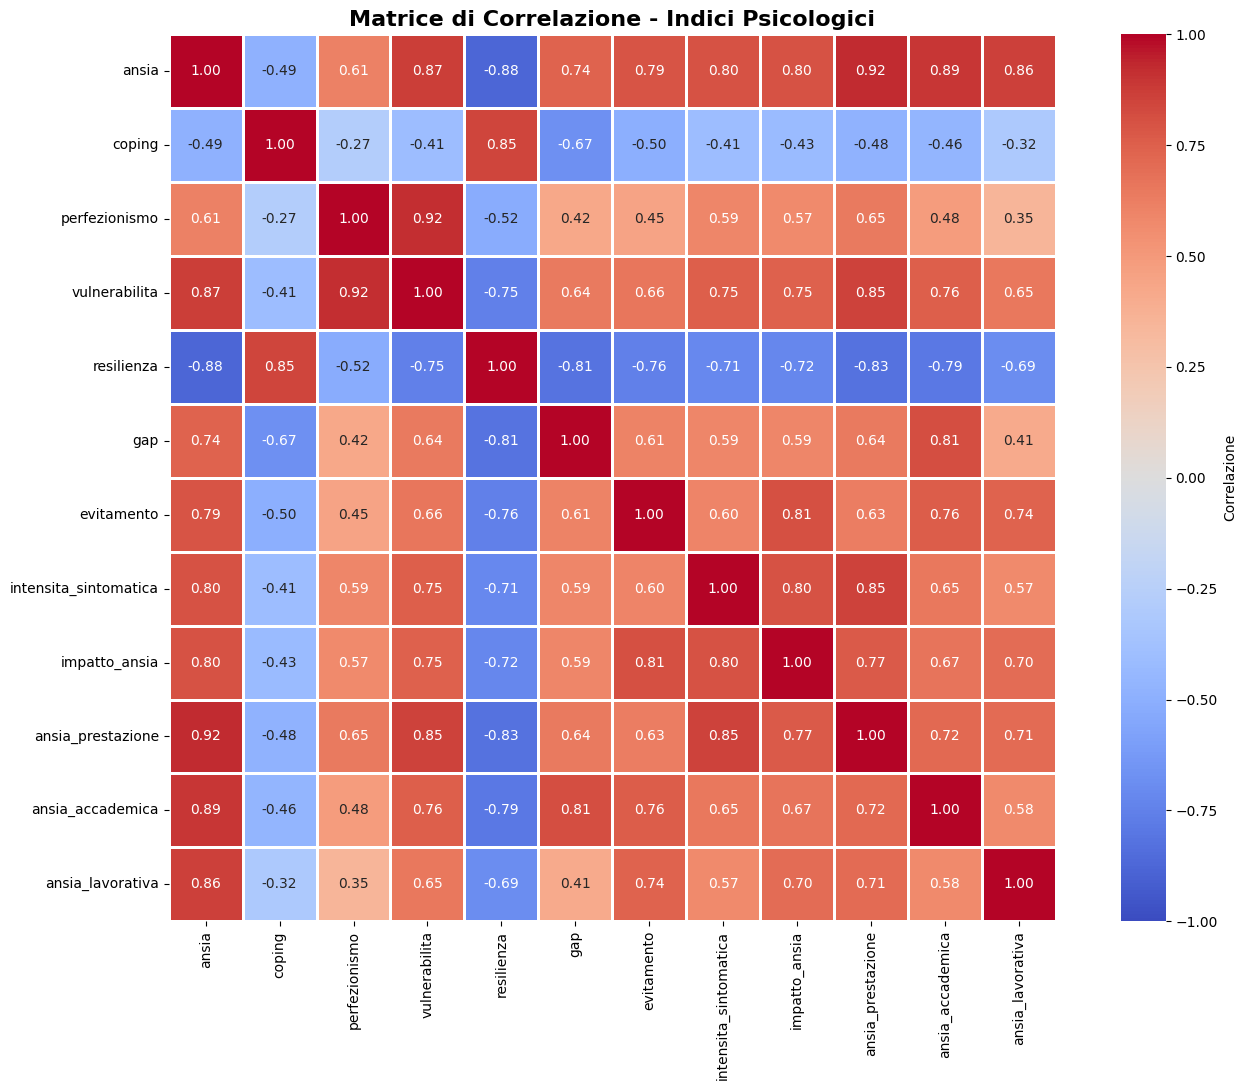

In [ ]:
# Matrice di correlazione Pearson
corr_matrix = df[vars_available].corr(method='pearson')

# Heatmap della matrice di correlazione
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'},
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione - Indici Psicologici', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig("matrice_correlazione")
plt.show()

In [176]:
df_reg = df.copy()

# eliminazione di tutte le colonne che non sono variabili numeriche o che sono 'Item_*'
numeric_cols = df_reg.select_dtypes(include=[np.number]).columns
df_reg = df_reg[numeric_cols]
df_reg = df_reg[[col for col in df_reg.columns if not col.startswith('Item_')]]
print(f"Dataset per regressione: {df_reg.shape[0]} record, {df_reg.shape[1]} variabili")


Dataset per regressione: 148 record, 15 variabili


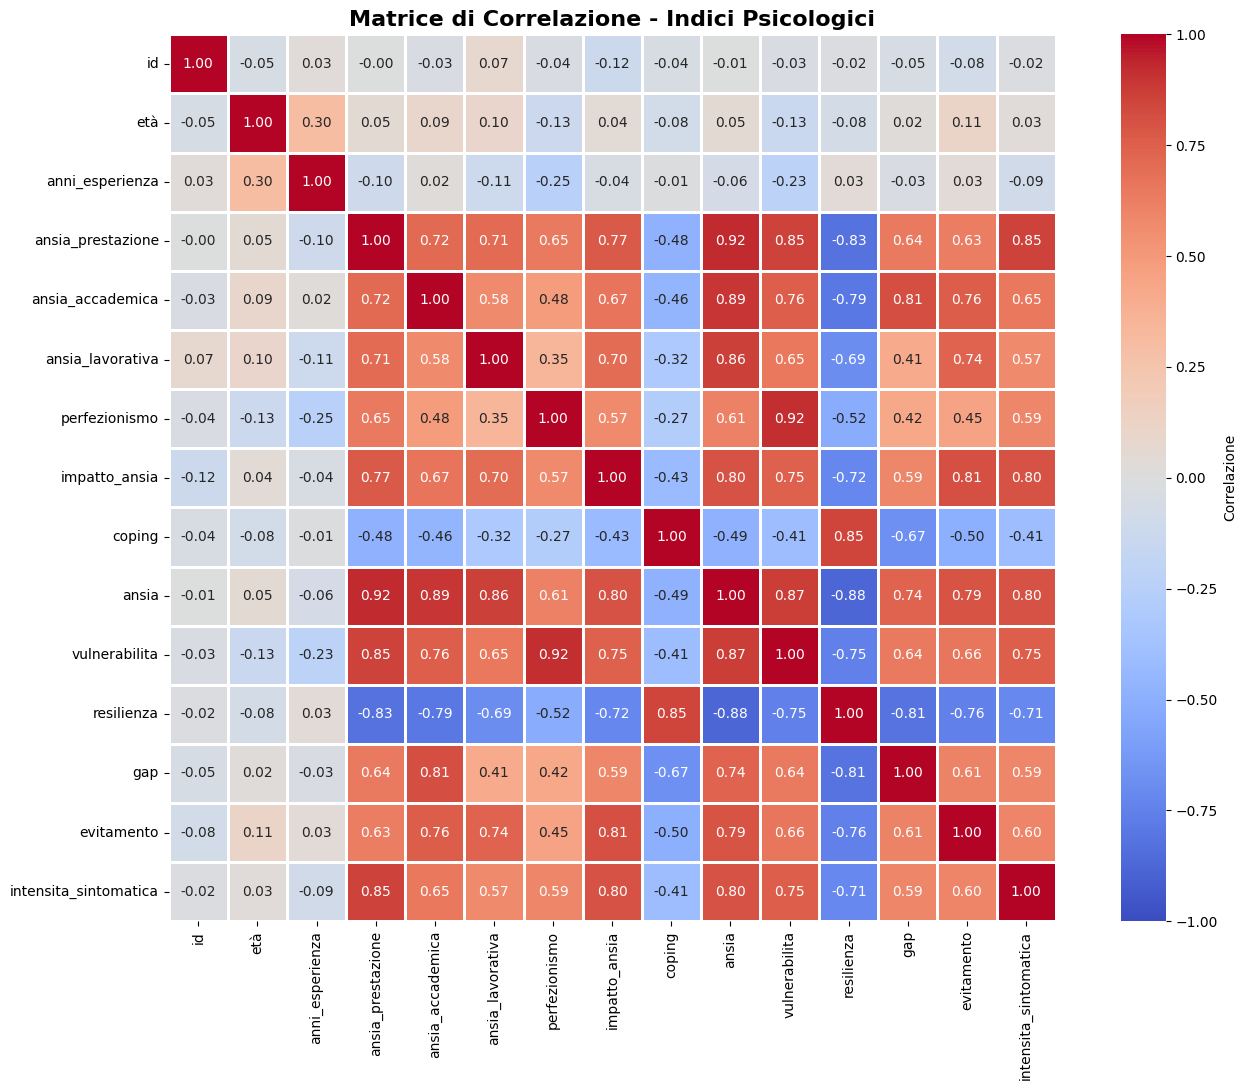

In [177]:
# Matrice di correlazione Pearson
corr_matrix = df_reg.corr(method='pearson')

# Heatmap della matrice di correlazione
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'},
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione - Indici Psicologici', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig("matrice_correlazione")
plt.show()

In [178]:
df_reg = df_reg.drop(columns=[
    'id', 
    'ansia_prestazione', 
    'ansia_accademica', 
    'ansia_lavorativa', 
    'vulnerabilita', #?
    'resilienza' #?
    ], errors='ignore')

df_reg

,età,anni_esperienza,perfezionismo,impatto_ansia,coping,ansia,gap,evitamento,intensita_sintomatica
0,24,5.0,4.00,4.6,1.50,4.416667,3.50,4.500000,5.000000
1,26,7.0,NaN,2.4,3.25,3.583333,-1.25,2.750000,2.500000
2,26,5.0,3.75,4.6,2.00,3.232143,1.00,3.333333,4.333333
3,26,5.0,4.25,3.2,2.75,1.958333,0.25,1.250000,3.333333
4,22,2.0,NaN,3.0,3.00,2.583333,-1.00,2.000000,2.000000
...,...,...,...,...,...,...,...,...,...
143,27,8.0,1.25,2.4,3.25,2.678571,0.75,1.666667,2.000000
144,25,5.0,3.25,3.2,3.50,3.208333,-1.50,1.750000,3.666667
145,21,3.0,NaN,1.2,3.25,2.000000,-2.25,1.000000,1.000000
146,21,1.0,NaN,3.0,3.00,3.690476,-1.00,3.250000,3.000000


In [179]:
df_reg = df_reg.dropna()
X = df_reg.drop(columns=['ansia'])
y = df_reg['ansia']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [180]:
mse, rmse, r2

(0.14218588124980336, np.float64(0.3770754317769899), 0.8371283014579413)

In [182]:
# Regressione Polinomiale grado 2
from matplotlib.pylab import reshape


X = reshape(X.values, (-1, 1)) if len(X.shape) == 1 else X.values
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

lin_reg_poly = LinearRegression()

lin_reg_poly.fit(X_poly, y)
y_pred_poly = lin_reg_poly.predict(X_poly)

mse_poly = mean_squared_error(y, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y, y_pred_poly)

print(f"Polinomiale grado 2 - R²: {r2_poly:.4f} | RMSE: {rmse_poly:.4f}")



Polinomiale grado 2 - R²: 0.9347 | RMSE: 0.2118
